# MIC-CC — Modelo Financiero Fase 4 · versión auditada y corregida

**Universidad EAN — ODEM** · Manuela Alcalá
Reconstrucción del modelo tras la auditoría cuantitativa del 26-jul-2026.

> Este cuaderno **no reemplaza ni modifica** `04_financial_model.ipynb` ni ningún archivo de
> `dataraw/`. Es un artefacto nuevo, con salidas propias en `outputs_v2/`. Las correcciones de
> datos se aplican **en memoria** mediante un registro de overrides trazable
> (`tabla_00_registro_correcciones.xlsx`), nunca editando la fuente.

## Correcciones aplicadas

| # | Hallazgo del modelo original | Corrección |
|---|---|---|
| 1 | **Incoherencia de incoterm.** Los 10 precios son FOB, y el modelo les restaba el flete internacional. Bajo FOB ese flete lo paga el comprador; bajo CFR el exportador lo cobra dentro del precio. En ninguno de los dos casos destruye margen. | Parámetro `pass_through_flete`. Con 1.0 (defecto) el flete se traslada; con 0.0 se reproduce el supuesto implícito original. **Origen real del −348% del carbón.** |
| 2 | **Tipo de cambio obsoleto.** Base FX de dic-2024 combinada con costos, tasas y precios de jul-2026. | Serie COP/CAD reconstruida en vivo 2014→hoy desde TRM oficial (Datos Abiertos BanRep) y Bank of Canada, con respaldo al archivo local. |
| 3 | **Episodios históricos en la divisa equivocada.** `pct_cambio` de `tabla_B6` está medido en TRM (COP/USD) y se aplicaba al COP/CAD. | Recalculados directamente sobre la serie COP/CAD construida. Se conserva el valor original para contraste. |
| 4 | **Desalineación temporal TRM ↔ Bank of Canada.** La TRM vigente el día *D* refleja el mercado de *D−1*; la cotización del BoC de *D* refleja *D*. | Alineación explícita (`alinear_trm_rezago`). Reduce la volatilidad anualizada de 16.55% a 13.93% — la diferencia era ruido de emparejamiento. |
| 5 | **Beneficio de Drawback fantasma.** Se sumaba 19% del costo importado a un margen cuyo costo nunca incluyó IVA, y las exportaciones son exentas con derecho a devolución (Arts. 481/485/489 ET). | Se modela el valor financiero real: el costo de financiar el IVA durante el trámite de devolución. Se conserva el 19% como cota superior explícita. |
| 6 | **Signo del forward invertido.** Con i_COP > i_CAD el forward COP/CAD cotiza *sobre* el spot: el exportador que vende CAD a plazo cobra prima, no paga costo. | Paridad cubierta exacta y **con signo**. La decisión de cobertura se replantea separando valor esperado y reducción de riesgo, e incorpora el spread NDF que el modelo original omitía. |
| 7 | **√T aplicado a cuantiles** de una distribución cuya normalidad el propio modelo rechaza. | Cuantil empírico multi-horizonte como método primario; √T se reporta solo como referencia, con el sesgo medido y el N efectivo por solapamiento. |
| 8 | **Retorno logarítmico compuesto con (1+r).** | `nivel × exp(r)`. |
| 9 | **Flores por vía marítima.** El 92% de la floricultura colombiana se exporta por aire desde El Dorado. Carbón modelado en contenedor siendo granel. | Dimensión `modo_transporte` (marítimo / aéreo / granel), clase de densidad y recargo reefer. |
| 10 | **IBR como costo de fondeo de una PYME**, dividido además entre 365 siendo nominal base 360. | Conversión nominal→efectiva anual correcta, y tasa de fondeo PYME (interés bancario corriente) con el IBR como piso. |
| 11 | **Precio del café** a 1.45 USD/lb, contradiciendo la fuente ICO/FNC citada; **USD/CAD** a 1.33 sin fecha coherente. | Overrides registrados y fechados. |
| 12 | **Escenarios ±10%/−15% arbitrarios.** | Cuantiles empíricos a 90 días de la propia serie. |
| 13 | **Costos accesorios de exportación ausentes** (flete interno, THC, agenciamiento, seguro, GMF). | Parámetro `costos_accesorios_pct_fob` con rango declarado. |
| 14 | **Verificaciones tautológicas** contadas como validación; fórmula de margen duplicada en 3 celdas. | Una sola implementación de cada fórmula + suite de pruebas que **puede fallar** (inversión, casos de control, detección de errores conocidos). |

**Lo que esta versión NO puede arreglar:** el factor de costo de producción de 0.60, uniforme y sin
fuente sectorial. Se conserva parametrizado y con análisis de sensibilidad, y se documenta de forma
explícita que **bajo ese supuesto el modelo no puede discriminar entre productos** — los rankings de
producto del cuaderno original son artefactos de ese factor, no evidencia.

## 0 · Configuración

Todo parámetro del modelo vive aquí, con su fuente y su fecha. Ninguna cifra de negocio aparece escrita dentro de una celda de cálculo.

In [1]:
from __future__ import annotations
import math, os, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

DATA, OUT = '../dataraw', '../outputs_v2'
os.makedirs(f'{OUT}/tables', exist_ok=True)
os.makedirs(f'{OUT}/figures', exist_ok=True)
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)

PARAMS = {
    # --- ventana de datos y riesgo ---------------------------------------
    'fx_inicio': '2014-01-01',
    'fx_fin': None,                       # None = hasta hoy
    'ventana_base_dias': 90,
    'alinear_trm_rezago': True,           # TRM(D) refleja mercado de D-1; BoC(D) refleja D
    'dias_habiles_anio': 252,
    'nivel_confianza': 0.95,
    'ventana_var_movil': 252,
    'horizontes_cobro': (30, 60, 90),

    # --- incoterm ---------------------------------------------------------
    # tabla_B4 cotiza los 10 productos 'Kilogramo (FOB)'.
    # 1.0 = el flete internacional se traslada al comprador (FOB puro, o CFR con
    #       traslado completo dentro del precio).
    # 0.0 = el exportador lo absorbe: supuesto implicito, y no declarado, del
    #       modelo original.
    'pass_through_flete': 1.0,
    'pass_through_sensibilidad': (0.0, 0.5, 1.0),

    # --- estructura de costos ---------------------------------------------
    # LIMITACION CONOCIDA, no resuelta: uniforme para los 10 productos y sin
    # fuente sectorial. Se acompana siempre de su sensibilidad.
    'factor_costo_produccion': 0.60,
    'factor_costo_sensibilidad': (0.50, 0.60, 0.70),
    # Costos accesorios de exportacion como % del valor FOB (flete interno a
    # puerto, THC, agenciamiento aduanero, DEX, seguro, GMF 4x1000). Ausentes por
    # completo en el modelo original. Rango tipico para PYME exportadora.
    'costos_accesorios_pct_fob': 0.055,
    'costos_accesorios_rango': (0.030, 0.080),

    # --- logistica --------------------------------------------------------
    # Payload util por clase de densidad. Un contenedor de 20 pies tiene ~33 m3 y
    # payload maximo ~28 t: solo la carga densa se acerca a ese limite; la carga
    # ligera "cuba" antes de "pesar".
    'payload_kg': {'densa': 20000, 'media': 12000, 'ligera': 7000},
    'recargo_reefer': 0.60,               # sobre tarifa de contenedor seco
    'flete_aereo_usd_kg': 2.80,           # all-in BOG -> Canada, perecederos
    'flete_aereo_rango': (2.00, 4.00),    # ESTIMACION: requiere cotizacion real
    'flete_granel_usd_kg': {'CTG-Montreal': 0.015, 'CTG-Vancouver': 0.022},
    'flete_granel_rango': (0.012, 0.030), # ESTIMACION: derivada de TC Panamax

    # --- tasas ------------------------------------------------------------
    'base_dias_ibr': 360,                 # el IBR se cotiza nominal base 360
    'tasa_fondeo_pyme_ea': 0.1919,        # IBC credito ordinario, jun-2026
    'usar_ibr_como_piso': True,

    # --- cobertura cambiaria ----------------------------------------------
    'spread_ndf_pyme': 0.0075,            # 75 pb ida y vuelta, ticket pequeno
    'spread_ndf_rango': (0.0030, 0.0150),
    'monto_minimo_ndf_usd': 10000,        # Davivienda, Tarea 7

    # --- Plan Vallejo / IVA ------------------------------------------------
    'tarifa_iva': 0.19,
    'dias_float_iva': 120,                # bimestre + radicacion + 50d (Art. 855 ET)
    'dias_float_rango': (50, 180),
    'exportador_con_derecho_devolucion': True,
}
p = PARAMS
print(f'{len(PARAMS)} parametros cargados.')

30 parametros cargados.


In [2]:
# Correcciones de datos verificadas contra fuente primaria. NO se altera ningun
# archivo de dataraw/: el override se aplica en memoria y queda registrado en
# outputs_v2/tables/tabla_00_registro_correcciones.xlsx
OVERRIDES = pd.DataFrame([
    dict(archivo='2tabla_B4_precios_referencia.xlsx', codigo_hs='0901.11.90.00',
         campo='precio_usd', valor_original=3.200, valor_corregido=8.490,
         fuente='Arabica ~3.55 USD/lb + prima Colombian Milds ~0.30 USD/lb = 3.85 USD/lb x 2.20462 lb/kg',
         fecha_verificacion='2026-07-26',
         motivo='El precio original (1.45 USD/lb) contradice la fuente ICO/FNC que el propio archivo cita.'),
    dict(archivo='2tabla_B4_precios_referencia.xlsx', codigo_hs='*',
         campo='tipo_cambio_usd_cad', valor_original=1.33, valor_corregido=1.4093,
         fuente='Bank of Canada, serie FXUSDCAD, 2026-07-24',
         fecha_verificacion='2026-07-26',
         motivo='El 1.33 del archivo no corresponde a ninguna fecha cercana a su fecha de consulta.'),
])

# Modo de transporte REAL por producto. El modelo original aplicaba flete de
# contenedor maritimo desde Cartagena a los 10 productos, incluidas las flores
# (92% se exportan por aire desde El Dorado) y el carbon (granel).
TRANSPORTE = pd.DataFrame([
    ('0901.11.90.00', 'maritimo', 'densa',  False),
    ('2701.12.00.00', 'granel',   'densa',  False),
    ('0804.50.00.00', 'maritimo', 'media',  True),
    ('0603.19.00.00', 'aereo',    'ligera', True),
    ('3004.32.00.00', 'maritimo', 'media',  False),
    ('6115.96.00.00', 'maritimo', 'ligera', False),
    ('7307.92.00.00', 'maritimo', 'densa',  False),
    ('0304.82.00.00', 'maritimo', 'media',  True),
    ('2008.19.00.00', 'maritimo', 'ligera', False),
    ('0603.11.00.00', 'aereo',    'ligera', True),
], columns=['codigo_hs', 'modo_transporte', 'clase_densidad', 'requiere_frio'])

OVERRIDES.to_excel(f'{OUT}/tables/tabla_00_registro_correcciones.xlsx', index=False)
display(OVERRIDES[['campo', 'valor_original', 'valor_corregido', 'fecha_verificacion']])
display(TRANSPORTE)

,campo,valor_original,valor_corregido,fecha_verificacion
0,precio_usd,3.20,8.4900,2026-07-26
1,tipo_cambio_usd_cad,1.33,1.4093,2026-07-26


,codigo_hs,modo_transporte,clase_densidad,requiere_frio
0,0901.11.90.00,maritimo,densa,False
1,2701.12.00.00,granel,densa,False
2,0804.50.00.00,maritimo,media,True
3,0603.19.00.00,aereo,ligera,True
4,3004.32.00.00,maritimo,media,False
5,6115.96.00.00,maritimo,ligera,False
6,7307.92.00.00,maritimo,densa,False
7,0304.82.00.00,maritimo,media,True
8,2008.19.00.00,maritimo,ligera,False
9,0603.11.00.00,aereo,ligera,True


## 1 · Capa de datos

Funciones puras, con respaldo local. El cuaderno original declaraba en su README que corría sin descargas externas mientras llamaba a una API en vivo, y nunca leía el archivo de respaldo que sí estaba en el repositorio. Aquí el respaldo funciona.

In [3]:
def descargar_trm(inicio, fin=None):
    """TRM oficial (Banco de la Republica via Datos Abiertos). vigenciadesde es el
    dia de vigencia; la tasa se calcula con operaciones del dia habil anterior."""
    url = ('https://www.datos.gov.co/resource/32sa-8pi3.json?$select=vigenciadesde,valor'
           f"&$where=vigenciadesde>'{inicio}T00:00:00'&$order=vigenciadesde&$limit=50000")
    d = pd.DataFrame(requests.get(url, timeout=120).json())
    d['fecha'] = pd.to_datetime(d['vigenciadesde'])
    d['TRM_COP_USD'] = d['valor'].astype(float)
    d = d[['fecha', 'TRM_COP_USD']].sort_values('fecha').reset_index(drop=True)
    return d[d['fecha'] <= pd.Timestamp(fin)] if fin else d


def descargar_usdcad(inicio, fin=None):
    """USD/CAD del Bank of Canada. FXUSDCAD existe desde 2017-01; para el tramo
    anterior se usa la serie legacy IEXE0101 (noon rate)."""
    fin = fin or pd.Timestamp.today().strftime('%Y-%m-%d')
    marcos = []
    for serie in ('IEXE0101', 'FXUSDCAD'):
        url = (f'https://www.bankofcanada.ca/valet/observations/{serie}/json'
               f'?start_date={inicio}&end_date={fin}')
        obs = requests.get(url, timeout=90).json().get('observations', [])
        filas = [{'fecha': o['d'], 'USDCAD': float(o[serie]['v'])}
                 for o in obs if serie in o and o[serie].get('v')]
        if filas:
            marcos.append(pd.DataFrame(filas))
    d = pd.concat(marcos, ignore_index=True)
    d['fecha'] = pd.to_datetime(d['fecha'])
    return d.drop_duplicates('fecha', keep='last').sort_values('fecha').reset_index(drop=True)


def cargar_usdcad_local(ruta):
    """Respaldo offline: el archivo de la Tarea 2 que el modelo original nunca leia."""
    d = pd.read_excel(ruta)
    cf = next(c for c in d.columns if 'fecha' in str(c).lower() or 'date' in str(c).lower())
    cv = next(c for c in d.columns if c != cf and pd.api.types.is_numeric_dtype(d[c]))
    d = d.rename(columns={cf: 'fecha', cv: 'USDCAD'})[['fecha', 'USDCAD']]
    d['fecha'] = pd.to_datetime(d['fecha'])
    return d.sort_values('fecha').reset_index(drop=True)


def construir_copcad(trm, usdcad, alinear_rezago=True):
    """COP/CAD = (COP/USD) / (CAD/USD).

    alinear_rezago=True empareja TRM(D) con USDCAD(D-1 habil): la TRM vigente el
    dia D se calcula con el mercado del dia habil anterior, mientras que la
    cotizacion del BoC del dia D refleja el mercado del dia D. Sin ese ajuste la
    serie cruzada mezcla dos fechas de mercado distintas e infla la varianza de
    los retornos con ruido de emparejamiento.
    """
    fx = usdcad.copy()
    if alinear_rezago:
        fx['fecha'] = fx['fecha'] + pd.tseries.offsets.BDay(1)
    d = trm.merge(fx, on='fecha', how='inner').sort_values('fecha').reset_index(drop=True)
    d['COP_CAD'] = d['TRM_COP_USD'] / d['USDCAD']
    d['retorno_log'] = np.log(d['COP_CAD'] / d['COP_CAD'].shift(1))
    return d

In [4]:
try:
    trm = descargar_trm(p['fx_inicio'], p['fx_fin']); origen_trm = 'Datos Abiertos (BanRep), en vivo'
except Exception as e:
    trm = (pd.read_excel(f'{DATA}/TRM_COP_USD_2020_2024.xlsx', sheet_name='Datos COP-USD')
             .rename(columns={'Fecha (aaaa/mm/dd)': 'fecha', 'TRM': 'TRM_COP_USD'}))
    trm['fecha'] = pd.to_datetime(trm['fecha']); origen_trm = f'archivo local (respaldo: {e})'

try:
    ucad = descargar_usdcad(p['fx_inicio'], p['fx_fin']); origen_cad = 'Bank of Canada Valet, en vivo'
except Exception as e:
    ucad = cargar_usdcad_local(f'{DATA}/USDCAD_2020_2024.xlsx'); origen_cad = f'archivo local (respaldo: {e})'

fx      = construir_copcad(trm, ucad, p['alinear_trm_rezago'])
fx_sin  = construir_copcad(trm, ucad, False)
r       = fx['retorno_log'].dropna()
fx_base = fx['COP_CAD'].rolling(p['ventana_base_dias']).mean().dropna().iloc[-1]
fx_spot = fx['COP_CAD'].iloc[-1]
trm_hoy = fx['TRM_COP_USD'].iloc[-1]

va = fx['retorno_log'].std() * np.sqrt(252)
vb = fx_sin['retorno_log'].std() * np.sqrt(252)
print(f'TRM: {origen_trm}\nUSD/CAD: {origen_cad}')
print(f'\nSerie COP/CAD: {len(fx)} observaciones, {fx.fecha.min().date()} -> {fx.fecha.max().date()}')
print(f'  spot  = {fx_spot:,.2f}   (TRM {trm_hoy:,.2f} / USDCAD {fx.USDCAD.iloc[-1]:.4f})')
print(f'  base  = {fx_base:,.2f}   (media movil {p["ventana_base_dias"]}d)')
print(f'\nEfecto de la alineacion temporal TRM(D) <-> BoC(D-1):')
print(f'  volatilidad anualizada alineada : {va:.4%}')
print(f'  volatilidad anualizada sin alinear: {vb:.4%}   (+{(vb-va)*1e4:.0f} pb de ruido de emparejamiento)')

TRM: Datos Abiertos (BanRep), en vivo
USD/CAD: Bank of Canada Valet, en vivo

Serie COP/CAD: 2311 observaciones, 2014-01-03 -> 2026-07-24
  spot  = 2,285.95   (TRM 3,219.31 / USDCAD 1.4083)
  base  = 2,607.78   (media movil 90d)

Efecto de la alineacion temporal TRM(D) <-> BoC(D-1):
  volatilidad anualizada alineada : 13.9321%
  volatilidad anualizada sin alinear: 16.5545%   (+262 pb de ruido de emparejamiento)


## 2 · Capa de modelo

Cada fórmula existe **una sola vez**. El cuaderno original tenía la ecuación de margen implementada tres veces de forma independiente (celdas 35, 54 y 60), lo que obliga a sincronizar tres ediciones para cualquier corrección.

In [5]:
# ---------------------------------------------------------------- riesgo
def var_historico(retornos, nivel_confianza=0.95):
    return float(np.percentile(retornos.dropna(), 100 * (1 - nivel_confianza)))


def expected_shortfall(retornos, nivel_confianza=0.95):
    x = retornos.dropna()
    return float(x[x <= var_historico(x, nivel_confianza)].mean())


def var_multihorizonte(retornos, precios, horizontes, nivel_confianza=0.95):
    """Cuantil EMPIRICO del retorno acumulado a T dias (metodo primario), junto al
    escalado raiz-del-tiempo (solo referencia). Escalar un CUANTIL por sqrt(T) es
    exacto unicamente bajo i.i.d. de distribucion estable; la normalidad se
    rechaza mas abajo con Jarque-Bera. Se reporta el N efectivo porque las
    ventanas de T dias se solapan y la muestra independiente es len/T."""
    v1 = var_historico(retornos, nivel_confianza)
    q = 100 * (1 - nivel_confianza)
    filas = []
    for T in horizontes:
        acum = np.log(precios / precios.shift(T)).dropna()
        filas.append({'horizonte_dias': T,
                      'var_empirico': float(np.percentile(acum, q)),
                      'var_sqrt_t': v1 * np.sqrt(T),
                      'peor_observado': float(acum.min()),
                      'n_ventanas_solapadas': len(acum),
                      'n_efectivo_independiente': round(len(acum) / T, 1)})
    d = pd.DataFrame(filas)
    d['sesgo_sqrt_t_pct'] = (d['var_sqrt_t'] / d['var_empirico'] - 1) * 100
    return d


def kupiec_pof(violaciones, n_obs, tasa_esperada):
    """Test de proporcion de fallos. LR ~ chi2(1); CDF chi2(1) = erf(sqrt(x/2))."""
    if not 0 < violaciones < n_obs:
        return float('nan'), float('nan')
    pe, ph = tasa_esperada, violaciones / n_obs
    lr = -2 * ((n_obs - violaciones) * math.log(1 - pe) + violaciones * math.log(pe)
               - (n_obs - violaciones) * math.log(1 - ph) - violaciones * math.log(ph))
    return lr, 1 - math.erf(math.sqrt(max(lr, 0) / 2))


def backtest_var_oos(retornos, ventana, nivel_confianza):
    """Backtest sin look-ahead: el VaR de t usa solo t-ventana .. t-1."""
    q = 100 * (1 - nivel_confianza)
    pron = retornos.shift(1).rolling(ventana).apply(lambda x: np.percentile(x, q), raw=True)
    cmp_ = pd.DataFrame({'real': retornos, 'pron': pron}).dropna()
    viol = int((cmp_['real'] < cmp_['pron']).sum())
    lr, pv = kupiec_pof(viol, len(cmp_), 1 - nivel_confianza)
    return {'violaciones': viol, 'n_obs': len(cmp_),
            'tasa_observada': viol / len(cmp_), 'lr': lr, 'p_value': pv}


def jarque_bera(retornos):
    """JB con los momentos POBLACIONALES (g1, g2), que es como esta definido el
    estadistico. pandas .skew()/.kurt() devuelven los estimadores corregidos por
    sesgo (G1, G2), que no son los que corresponden aqui."""
    x = retornos.dropna().to_numpy()
    n = len(x); d = x - x.mean()
    m2, m3, m4 = (d**2).mean(), (d**3).mean(), (d**4).mean()
    g1, g2 = m3 / m2**1.5, m4 / m2**2 - 3
    jb = n / 6 * (g1**2 + g2**2 / 4)
    return {'n': n, 'asimetria': g1, 'curtosis_exceso': g2, 'jb': jb,
            'p_value': math.exp(-jb / 2)}


def nivel_desde_retorno_log(nivel_base, retorno_log):
    """Un retorno logaritmico se compone con exp(), no con (1+r)."""
    return nivel_base * math.exp(retorno_log)

In [6]:
# ---------------------------------------------------------------- margen
def margen(precio_fob_cad, fx, fx_base, costo_produccion_cop, pct_importado,
           costo_logistico_cop, costos_accesorios_pct=0.0, pass_through_flete=1.0):
    """UNICA implementacion de la ecuacion de margen del modelo.

    COHERENCIA DE INCOTERM (correccion critica). Los 10 precios de tabla_B4 estan
    cotizados 'Kilogramo (FOB)'. Bajo FOB el flete internacional lo paga el
    COMPRADOR; bajo CFR/CIF lo paga el exportador pero se lo factura dentro del
    precio. En los dos casos el flete NO destruye margen. El modelo original lo
    restaba de un ingreso FOB que nunca lo incluyo, cobrandolo dos veces: ese es
    el origen del -348% del carbon, no la economia del producto.

        pass_through_flete = 1.0 -> traslado completo al comprador (defecto)
        pass_through_flete = 0.0 -> el exportador absorbe todo el flete
                                    (supuesto implicito del modelo original)

    La porcion importada del costo de produccion escala con el tipo de cambio
    (cobertura natural); la nacional y el flete no. Los costos accesorios de
    exportacion se cobran sobre el valor FOB y son del exportador bajo cualquier
    incoterm.
    """
    ingreso_fob = precio_fob_cad * fx
    ingreso = ingreso_fob + pass_through_flete * costo_logistico_cop
    costo_importado = costo_produccion_cop * pct_importado * (fx / fx_base)
    costo_nacional = costo_produccion_cop * (1 - pct_importado)
    costo_accesorio = ingreso_fob * costos_accesorios_pct
    costo_total = costo_importado + costo_nacional + costo_logistico_cop + costo_accesorio
    m = ingreso - costo_total
    return {'ingreso_fob_cop': ingreso_fob, 'ingreso_cop': ingreso,
            'costo_importado_cop': costo_importado, 'costo_nacional_cop': costo_nacional,
            'costo_logistico_cop': costo_logistico_cop, 'costo_accesorio_cop': costo_accesorio,
            'costo_total_cop': costo_total, 'margen_cop': m,
            'margen_pct': m / ingreso * 100, 'margen_pct_sobre_fob': m / ingreso_fob * 100}


def breakeven_fx(precio_fob_cad, fx_base, costo_produccion_cop, pct_importado,
                 costo_logistico_cop, costos_accesorios_pct=0.0, pass_through_flete=1.0):
    """FX al que el margen es cero, resuelto ANALITICAMENTE incluyendo la cobertura
    natural (el costo importado depende del propio FX que se despeja):

        P*X + pt*L - Ci*(X/Xb) - Cn - L - a*P*X = 0
        X * (P*(1-a) - Ci/Xb) = Cn + (1-pt)*L

    Con pt=1 el flete se cancela y el breakeven NO depende de la ruta: bajo
    traslado completo, elegir Montreal o Vancouver no altera la economia del
    exportador. Esa invariancia es un resultado del modelo, no un defecto.
    """
    ci = costo_produccion_cop * pct_importado
    cn = costo_produccion_cop * (1 - pct_importado)
    denom = precio_fob_cad * (1 - costos_accesorios_pct) - ci / fx_base
    if denom <= 0:
        return float('inf')
    return (cn + (1 - pass_through_flete) * costo_logistico_cop) / denom


def clasificar_riesgo(breakeven, fx_adverso, fx_muy_adverso):
    """Umbrales pasados EXPLICITAMENTE. El modelo original los ligaba como
    argumentos por defecto en tiempo de definicion, congelando el tipo de cambio
    de clasificacion en silencio ante cualquier recalibracion."""
    if fx_adverso < breakeven:
        return 'Rojo'
    if fx_muy_adverso < breakeven:
        return 'Amarillo'
    return 'Verde'

In [7]:
# ------------------------------------------------------- logistica y tasas
def costo_logistico_cop_kg(modo, clase_densidad, requiere_frio, ruta,
                           tarifa_contenedor_usd, trm, cfg):
    """COP por kilogramo segun el modo de transporte REAL del producto."""
    if modo == 'aereo':
        usd_kg = cfg['flete_aereo_usd_kg']
        detalle = f'aereo BOG-Canada {usd_kg:.2f} USD/kg'
    elif modo == 'granel':
        usd_kg = cfg['flete_granel_usd_kg'][ruta]
        detalle = f'granel {usd_kg:.3f} USD/kg'
    else:
        payload = cfg['payload_kg'][clase_densidad]
        tarifa = tarifa_contenedor_usd * (1 + cfg['recargo_reefer'] if requiere_frio else 1)
        usd_kg = tarifa / payload
        detalle = (f'contenedor {tarifa:,.0f} USD / {payload:,} kg '
                   f'({clase_densidad}{", reefer" if requiere_frio else ""})')
    return usd_kg * trm, detalle


def tasa_diaria_desde_ea(tasa_ea, dias):
    """Factor compuesto correcto para una tasa efectiva anual."""
    return (1 + tasa_ea) ** (dias / 365) - 1


def nominal_a_ea(tasa_nominal, base_dias=360):
    """El IBR se cotiza nominal base 360. Su equivalente efectivo anual."""
    return (1 + tasa_nominal / base_dias) ** 365 - 1


def costo_capital_trabajo(costo_total_cop, tasa_ea, dias):
    return costo_total_cop * tasa_diaria_desde_ea(tasa_ea, dias)


def puntos_forward_cip(i_local_ea, i_extranjera_ea, dias):
    """Paridad cubierta EXACTA y CON SIGNO:  F/S - 1 = (1+i_loc)^t/(1+i_ext)^t - 1

    Positivo => el forward COP/CAD cotiza SOBRE el spot. Un exportador que vende
    CAD a plazo recibe ese diferencial como PRIMA, no lo paga como costo. El
    modelo original tomaba abs() de este numero y lo llamaba 'costo de cobertura'."""
    t = dias / 365
    return (1 + i_local_ea) ** t / (1 + i_extranjera_ea) ** t - 1


def evaluar_cobertura(ingreso_cop, prima_forward_pct, spread_ndf, var_pct, es_pct):
    """Decision de cobertura planteada correctamente.

    El modelo original comparaba un costo cierto contra un cuantil de cola al 5%
    -magnitudes no comparables-, y con |puntos_forward| ~ T frente a |VaR| ~ sqrt(T)
    la desigualdad no podia invertirse a ningun horizonte: la conclusion 'Cubrirse'
    estaba forzada por construccion. Aqui se separan las dos preguntas:

      1) Valor esperado. Bajo camino aleatorio E[S_T] = S, asi que cubrirse aporta
         la prima del forward menos el costo de transaccion (spread NDF).
      2) Valor de reduccion de riesgo. El forward elimina la cola completa. Se
         reporta aparte, sin sumarlo al valor esperado.
    """
    prima_neta = prima_forward_pct - spread_ndf
    return {'prima_forward_pct': prima_forward_pct, 'spread_ndf_pct': spread_ndf,
            'valor_esperado_neto_pct': prima_neta,
            'valor_esperado_neto_cop': prima_neta * ingreso_cop,
            'cola_var_evitada_pct': abs(var_pct), 'cola_es_evitada_pct': abs(es_pct),
            'cola_var_evitada_cop': abs(var_pct) * ingreso_cop,
            'recomendacion': ('Cubrirse (valor esperado positivo + elimina cola)'
                              if prima_neta > 0 else
                              'Cubrirse solo por reduccion de riesgo (valor esperado negativo)')}


def beneficio_plan_vallejo(costo_importado_cop, aplica, cfg):
    """Valor financiero REAL del Plan Vallejo para un exportador.

    El IVA sobre insumos importados no es un costo hundido para un exportador: las
    exportaciones son exentas con derecho a devolucion (Arts. 481, 485, 489 y 850
    ET), asi que ese IVA se recupera de todos modos. Lo que el Plan Vallejo evita
    es FINANCIAR ese IVA mientras se tramita la devolucion.

        beneficio = IVA x costo_importado x [(1+i)^(dias_float/365) - 1]

    Se conserva aparte el 19% bruto como COTA SUPERIOR: solo seria el beneficio
    real si la empresa no tuviera derecho o acceso efectivo a la devolucion.
    El modelo original sumaba ese 19% completo al margen, acreditando un ahorro
    sobre un costo que su propia base de costos nunca cargo."""
    if not aplica:
        return {'beneficio_financiero_cop': 0.0, 'cota_superior_19pct_cop': 0.0}
    iva = cfg['tarifa_iva'] * costo_importado_cop
    carry = tasa_diaria_desde_ea(cfg['tasa_fondeo_pyme_ea'], cfg['dias_float_iva'])
    return {'beneficio_financiero_cop': iva * carry if cfg['exportador_con_derecho_devolucion'] else iva,
            'cota_superior_19pct_cop': iva}


def normalizar(valor):
    t = str(valor).strip().lower()
    return ''.join(c for c in unicodedata.normalize('NFKD', t) if not unicodedata.combining(c))

## 3 · Riesgo cambiario COP/CAD

VaR histórico, Expected Shortfall, backtest fuera de muestra y normalidad. El cuantil multi-horizonte se calcula de forma **empírica**, no escalando por √T.

In [8]:
v95 = var_historico(r, p['nivel_confianza'])
v99 = var_historico(r, 0.99)
es95 = expected_shortfall(r, p['nivel_confianza'])
jb = jarque_bera(r)
oos = backtest_var_oos(fx['retorno_log'], p['ventana_var_movil'], p['nivel_confianza'])
mh = var_multihorizonte(r, fx['COP_CAD'], p['horizontes_cobro'], p['nivel_confianza'])
vol_anual = r.std() * np.sqrt(p['dias_habiles_anio'])

print(f'Volatilidad anualizada : {vol_anual:.4%}')
print(f'VaR 1d 95%             : {v95:.4%}')
print(f'VaR 1d 99%             : {v99:.4%}')
print(f'Expected Shortfall 95% : {es95:.4%}')
print(f'\nJarque-Bera = {jb["jb"]:.1f} (p = {jb["p_value"]:.2e}) | asimetria {jb["asimetria"]:.3f} | '
      f'curtosis exceso {jb["curtosis_exceso"]:.3f}')
print(f'  -> normalidad {"NO se rechaza" if jb["p_value"] >= .05 else "RECHAZADA"}: '
      f'{"se puede usar" if jb["p_value"] >= .05 else "NO se debe usar"} escalado sqrt(T) sobre cuantiles.')

print(f'\nBacktest Kupiec fuera de muestra (ventana {p["ventana_var_movil"]}d, sin look-ahead):')
print(f'  {oos["violaciones"]} violaciones en {oos["n_obs"]} dias = {oos["tasa_observada"]:.2%} '
      f'(esperado {1-p["nivel_confianza"]:.2%}) | LR = {oos["lr"]:.3f} | p = {oos["p_value"]:.4f}')
print(f'  -> {"calibracion aceptable" if oos["p_value"] >= .05 else "SE RECHAZA la buena calibracion al 5%: el VaR movil subestima levemente el riesgo"}')
display(mh.round(4))
print('El escalado sqrt(T) sobreestima el cuantil empirico entre '
      f'{mh.sesgo_sqrt_t_pct.min():.0f}% y {mh.sesgo_sqrt_t_pct.max():.0f}%. Se usa el empirico.')

Volatilidad anualizada : 13.9321%
VaR 1d 95%             : -1.3050%
VaR 1d 99%             : -2.3363%
Expected Shortfall 95% : -1.9269%

Jarque-Bera = 1009.8 (p = 5.40e-220) | asimetria 0.339 | curtosis exceso 3.167
  -> normalidad RECHAZADA: NO se debe usar escalado sqrt(T) sobre cuantiles.

Backtest Kupiec fuera de muestra (ventana 252d, sin look-ahead):
  123 violaciones en 2058 dias = 5.98% (esperado 5.00%) | LR = 3.900 | p = 0.0483
  -> SE RECHAZA la buena calibracion al 5%: el VaR movil subestima levemente el riesgo


,horizonte_dias,var_empirico,var_sqrt_t,peor_observado,n_ventanas_solapadas,n_efectivo_independiente,sesgo_sqrt_t_pct
0,30,-0.0631,-0.0715,-0.1927,2281,76.0,13.1956
1,60,-0.0861,-0.1011,-0.1667,2251,37.5,17.3930
2,90,-0.1098,-0.1238,-0.1958,2221,24.7,12.8040


El escalado sqrt(T) sobreestima el cuantil empirico entre 13% y 17%. Se usa el empirico.


In [9]:
# Escenarios anclados a la distribucion empirica de la propia serie, en vez de
# los +10% / -15% arbitrarios y sin fuente del modelo original.
acum90 = np.log(fx['COP_CAD'] / fx['COP_CAD'].shift(90)).dropna()
q05, q95 = np.percentile(acum90, 5), np.percentile(acum90, 95)
ESC = {'Pesimista': nivel_desde_retorno_log(fx_base, q05),
       'Base':      fx_base,
       'Optimista': nivel_desde_retorno_log(fx_base, q95)}

var90 = mh.loc[mh.horizonte_dias == 90, 'var_empirico'].iloc[0]
peor90 = mh.loc[mh.horizonte_dias == 90, 'peor_observado'].iloc[0]
fx_var90 = nivel_desde_retorno_log(fx_base, var90)     # exp(), no (1+r)
fx_peor90 = nivel_desde_retorno_log(fx_base, peor90)

print('Escenarios COP/CAD (cuantiles empiricos a 90 dias):')
for k, v in ESC.items():
    print(f'  {k:10s} {v:9,.2f}   ({(v/fx_base-1)*100:+6.2f}% vs base)')
print(f'\n  FX en VaR 90d empirico       {fx_var90:9,.2f}')
print(f'  FX en peor ventana 90d real  {fx_peor90:9,.2f}')
print(f'  FX spot vigente              {fx_spot:9,.2f}')
print(f'\nComparacion con el metodo original (nivel = base*(1+r) sobre un retorno log):')
print(f'  correcto base*exp(r) = {fx_var90:,.2f} | metodo original base*(1+r) = {fx_base*(1+var90):,.2f} '
      f'| diferencia {fx_var90 - fx_base*(1+var90):,.2f} COP')

Escenarios COP/CAD (cuantiles empiricos a 90 dias):
  Pesimista   2,336.71   (-10.39% vs base)
  Base        2,607.78   ( +0.00% vs base)
  Optimista   2,964.08   (+13.66% vs base)

  FX en VaR 90d empirico        2,336.71
  FX en peor ventana 90d real   2,143.96
  FX spot vigente               2,285.95

Comparacion con el metodo original (nivel = base*(1+r) sobre un retorno log):
  correcto base*exp(r) = 2,336.71 | metodo original base*(1+r) = 2,321.57 | diferencia 15.15 COP


## 4 · Pruebas

A diferencia de las del cuaderno original —donde varias verificaban identidades algebraicas que no podían fallar (`razón 60d/30d = 2.000`, `correlación = 1.000` predicha de antemano, `costo_fin/costo_total` constante por construcción)— estas pruebas **pueden fallar**: invierten funciones por caminos independientes, usan casos de control con respuesta conocida y verifican que los detectores detecten.

In [10]:
def suite_pruebas(prod_muestra=None):
    fallos = []
    def chk(nombre, cond):
        if not cond:
            fallos.append(nombre)

    # 1. INVERSION: evaluar el margen exactamente en el breakeven debe dar cero.
    #    breakeven se resuelve analiticamente, margen se evalua numericamente:
    #    son dos caminos distintos, asi que la prueba puede fallar de verdad.
    for pt in (0.0, 0.5, 1.0):
        for pi in (0.0, 0.3, 0.65):
            bk = breakeven_fx(4.25, 2600, 6600, pi, 900, 0.055, pt)
            m = margen(4.25, bk, 2600, 6600, pi, 900, 0.055, pt)
            chk(f'breakeven->margen=0 (pt={pt}, imp={pi})', abs(m['margen_pct']) < 1e-8)

    # 2. La cobertura natural debe REDUCIR la sensibilidad del margen al FX,
    #    en las dos direcciones (si solo mejorase, no seria un hedge).
    def sensibilidad(pct_imp):
        a = margen(4.25, 2600*0.9, 2600, 6600, pct_imp, 900, 0.055)['margen_pct']
        b = margen(4.25, 2600*1.1, 2600, 6600, pct_imp, 900, 0.055)['margen_pct']
        return b - a
    chk('hedge reduce sensibilidad', sensibilidad(0.65) < sensibilidad(0.0))
    chk('hedge sin insumos importados no hace nada', abs(sensibilidad(0.0) - sensibilidad(0.0)) < 1e-12)

    # 3. Signo del forward en ambas direcciones del diferencial.
    chk('forward con prima si i_local > i_ext', puntos_forward_cip(0.12, 0.0225, 90) > 0)
    chk('forward con descuento si i_local < i_ext', puntos_forward_cip(0.01, 0.0225, 90) < 0)

    # 4. exp() vs (1+r): para r<0, exp(r) > 1+r estrictamente.
    chk('log->nivel usa exp', nivel_desde_retorno_log(3000, -0.1381) > 3000*(1-0.1381))

    # 5. Kupiec debe DETECTAR mala calibracion y ACEPTAR buena calibracion.
    chk('Kupiec rechaza 10% de violaciones', kupiec_pof(100, 1000, 0.05)[1] < 0.05)
    chk('Kupiec acepta 5% de violaciones',   kupiec_pof(50, 1000, 0.05)[1] > 0.05)

    # 6. Jarque-Bera contra casos de control con respuesta conocida.
    rng = np.random.default_rng(7)
    chk('JB rechaza t de Student(3)', jarque_bera(pd.Series(rng.standard_t(3, 4000)))['p_value'] < 0.05)
    chk('JB no rechaza una normal',   jarque_bera(pd.Series(rng.standard_normal(4000)))['p_value'] > 0.05)

    # 7. El beneficio del Plan Vallejo debe ser muy inferior al 19% bruto.
    b = beneficio_plan_vallejo(100_000, True, p)
    chk('Plan Vallejo << 19% bruto', b['beneficio_financiero_cop'] < 0.15*b['cota_superior_19pct_cop'])
    chk('sin insumo importado no hay beneficio',
        beneficio_plan_vallejo(0.0, True, p)['beneficio_financiero_cop'] == 0)
    chk('sin elegibilidad no hay beneficio',
        beneficio_plan_vallejo(100_000, False, p)['beneficio_financiero_cop'] == 0)

    # 8. Tasa compuesta < tasa simple para plazos menores a un anio.
    chk('tasa compuesta < simple', tasa_diaria_desde_ea(0.19, 90) < 0.19*90/365)

    # 9. Monotonicidad economica: el margen del exportador crece con el FX.
    ms = [margen(4.0, f, 2600, 6600, 0.3, 900, 0.055)['margen_pct'] for f in (2000, 2400, 2800, 3200)]
    chk('margen crece con el FX', all(np.diff(ms) > 0))

    # 10. INCOTERM: con traslado completo el flete no puede alterar el margen en COP;
    #     con traslado nulo si debe alterarlo. Es la prueba que el modelo original
    #     habria fallado.
    m_bajo = margen(4.0, 2300, 2600, 6000, 0.3,   200, 0.055, 1.0)['margen_cop']
    m_alto = margen(4.0, 2300, 2600, 6000, 0.3, 9_000, 0.055, 1.0)['margen_cop']
    chk('flete no altera el margen COP con pass-through=1', abs(m_bajo - m_alto) < 1e-9)
    m_abs = margen(4.0, 2300, 2600, 6000, 0.3, 9_000, 0.055, 0.0)['margen_cop']
    chk('flete si altera el margen COP con pass-through=0', m_abs < m_alto - 1000)

    # 11. El semaforo debe responder a los umbrales, no a un estado congelado.
    chk('semaforo Rojo',     clasificar_riesgo(3000, 2500, 2300) == 'Rojo')
    chk('semaforo Amarillo', clasificar_riesgo(2400, 2500, 2300) == 'Amarillo')
    chk('semaforo Verde',    clasificar_riesgo(2000, 2500, 2300) == 'Verde')

    return fallos

_fallos = suite_pruebas()
print(f'Pruebas ejecutadas. Fallos: {len(_fallos)}')
if _fallos:
    for f_ in _fallos:
        print('  FALLO:', f_)
assert not _fallos, _fallos
print('Todas las pruebas pasaron.')

Pruebas ejecutadas. Fallos: 0
Todas las pruebas pasaron.


## 5 · Productos, precios y logística por modo de transporte real

In [11]:
prod = pd.read_excel(f'{DATA}/2tabla_B4_precios_referencia.xlsx')
prod.columns = ['numero', 'producto', 'codigo_hs', 'precio_usd', 'unidad',
                'tc_usd_cad', 'precio_cad', 'fuente', 'fecha_consulta']
prod['precio_usd_original'] = prod['precio_usd']
prod['precio_cad_original'] = prod['precio_cad']

for _, o in OVERRIDES.iterrows():
    if o.campo == 'precio_usd':
        prod.loc[prod.codigo_hs == o.codigo_hs, 'precio_usd'] = o.valor_corregido
    elif o.campo == 'tipo_cambio_usd_cad':
        prod['tc_usd_cad'] = o.valor_corregido
prod['precio_cad'] = prod['precio_usd'] * prod['tc_usd_cad']

costos = pd.read_excel(f'{DATA}/tabla_B9_estructura_costos.xlsx')
costos['pct_importado'] = costos['pct_importado'] / 100
prod = prod.merge(costos[['codigo_hs', 'pct_importado']], on='codigo_hs', validate='1:1')
prod = prod.merge(TRANSPORTE, on='codigo_hs', validate='1:1')
prod['costo_produccion_cop'] = prod['precio_cad'] * fx_base * p['factor_costo_produccion']

print(f'Incoterm declarado en la fuente: {prod["unidad"].unique()}')
display(prod[['producto', 'codigo_hs', 'precio_cad_original', 'precio_cad',
              'pct_importado', 'modo_transporte', 'clase_densidad', 'requiere_frio']].round(3))

Incoterm declarado en la fuente: <StringArray>
['Kilogramo (FOB)']
Length: 1, dtype: str


,producto,codigo_hs,precio_cad_original,precio_cad,pct_importado,modo_transporte,clase_densidad,requiere_frio
0,Café sin tostar,0901.11.90.00,4.256,11.965,0.25,maritimo,densa,False
1,Carbón bituminoso,2701.12.00.00,0.117,0.124,0.15,granel,densa,False
2,Frutas tropicales (guayaba/mango),0804.50.00.00,1.596,1.691,0.30,maritimo,media,True
3,Flores frescas otras (pompones/hortensias),0603.19.00.00,3.325,3.523,0.30,aereo,ligera,True
4,Medicamentos corticosteroides,3004.32.00.00,37.240,39.460,0.65,maritimo,media,False
5,Medias/calcetines fibra sintética,6115.96.00.00,9.044,9.583,0.55,maritimo,ligera,False
6,Accesorios tubería hierro/acero,7307.92.00.00,2.793,2.960,0.40,maritimo,densa,False
7,Filetes de trucha congelados,0304.82.00.00,7.315,7.751,0.55,maritimo,media,True
8,Nueces y semillas preparadas,2008.19.00.00,5.719,6.060,0.55,maritimo,ligera,False
9,Rosas frescas cortadas,0603.11.00.00,3.724,3.946,0.30,aereo,ligera,True


In [12]:
fl = pd.read_excel(f'{DATA}/costos_logisticos_rutas.xlsx')
fl['tarifa_usd'] = fl['tarifa_usd_teu'].apply(
    lambda v: float(str(v).replace('$', '').replace(' ', '').replace('.', '').replace(',', '.')))
RUTAS = {'Cartagena CO - Montreal CA': 'CTG-Montreal',
         'Cartagena CO - Vancouver CA': 'CTG-Vancouver'}
fl = fl[fl.ruta.isin(RUTAS) & (fl.tipo_contenedor == '20 pies')].copy()
fl['ruta_modelo'] = fl.ruta.map(RUTAS)
tarifa = fl.groupby('ruta_modelo')['tarifa_usd'].mean().to_dict()

# TRM VIGENTE, no la de cierre de 2024: convertir cotizaciones de flete de 2026
# con una TRM 37% mas alta inflaba el costo logistico en pesos.
print(f'TRM usada para convertir fletes: {trm_hoy:,.2f} ({fx.fecha.iloc[-1].date()})')
print(f'Tarifas de contenedor 20 pies: ' + ' | '.join(f'{k} {v:,.0f} USD' for k, v in tarifa.items()))

filas = []
for _, x in prod.iterrows():
    for ruta in tarifa:
        c, det = costo_logistico_cop_kg(x.modo_transporte, x.clase_densidad,
                                        x.requiere_frio, ruta, tarifa[ruta], trm_hoy, p)
        filas.append({'codigo_hs': x.codigo_hs, 'producto': x['producto'], 'ruta': ruta,
                      'modo_transporte': x.modo_transporte,
                      'costo_logistico_cop_kg': c, 'detalle': det})
fletes = pd.DataFrame(filas)
display(fletes.pivot_table(index=['producto', 'modo_transporte'], columns='ruta',
                           values='costo_logistico_cop_kg').round(0))

def flete_de(hs, ruta):
    return fletes.loc[(fletes.codigo_hs == hs) & (fletes.ruta == ruta), 'costo_logistico_cop_kg'].iloc[0]

TRM usada para convertir fletes: 3,219.31 (2026-07-24)
Tarifas de contenedor 20 pies: CTG-Montreal 1,046 USD | CTG-Vancouver 5,281 USD


,ruta,CTG-Montreal,CTG-Vancouver
producto,modo_transporte,,
Accesorios tubería hierro/acero,maritimo,168.0,850.0
Café sin tostar,maritimo,168.0,850.0
Carbón bituminoso,granel,48.0,71.0
Filetes de trucha congelados,maritimo,449.0,2267.0
Flores frescas otras (pompones/hortensias),aereo,9014.0,9014.0
Frutas tropicales (guayaba/mango),maritimo,449.0,2267.0
Medias/calcetines fibra sintética,maritimo,481.0,2429.0
Medicamentos corticosteroides,maritimo,281.0,1417.0
Nueces y semillas preparadas,maritimo,481.0,2429.0


## 6 · Márgenes por escenario y ruta (60 combinaciones)

Se reporta el margen bajo el tratamiento correcto del incoterm y, en paralelo, el que producía el método original (flete absorbido) para que la diferencia quede visible.

In [13]:
filas = []
for _, x in prod.iterrows():
    for ruta in tarifa:
        cl = flete_de(x.codigo_hs, ruta)
        for esc, tc in ESC.items():
            comp = margen(x.precio_cad, tc, fx_base, x.costo_produccion_cop, x.pct_importado,
                          cl, p['costos_accesorios_pct_fob'], p['pass_through_flete'])
            orig = margen(x.precio_cad, tc, fx_base, x.costo_produccion_cop, 0.0, cl, 0.0, 0.0)
            filas.append({'producto': x['producto'], 'codigo_hs': x.codigo_hs, 'ruta': ruta,
                          'escenario': esc, 'modo_transporte': x.modo_transporte, 'COPCAD': tc,
                          'pct_importado': x.pct_importado,
                          'ingreso_fob_cop': comp['ingreso_fob_cop'], 'ingreso_cop': comp['ingreso_cop'],
                          'costo_total_cop': comp['costo_total_cop'],
                          'costo_importado_cop': comp['costo_importado_cop'],
                          'costo_accesorio_cop': comp['costo_accesorio_cop'],
                          'margen_cop': comp['margen_cop'], 'margen_pct': comp['margen_pct'],
                          'margen_pct_sobre_fob': comp['margen_pct_sobre_fob'],
                          'margen_pct_metodo_original': orig['margen_pct']})
tabla_margenes = pd.DataFrame(filas)
assert len(tabla_margenes) == len(prod) * len(tarifa) * len(ESC) == 60

cmp_inc = (tabla_margenes[tabla_margenes.escenario == 'Base']
           .pivot_table(index='producto', columns='ruta',
                        values=['margen_pct', 'margen_pct_metodo_original']).round(1))
print('Margen en escenario Base: tratamiento correcto vs. metodo original\n')
display(cmp_inc)

Margen en escenario Base: tratamiento correcto vs. metodo original



margen_pct               margen_pct_metodo_original              
ruta                                       CTG-Montreal CTG-Vancouver               CTG-Montreal CTG-Vancouver
producto                                                                                                      
Accesorios tubería hierro/acero                    33.8          31.1                       37.8          29.0
Café sin tostar                                    34.3          33.6                       39.5          37.3
Carbón bituminoso                                  30.0          28.3                       25.1          18.1
Filetes de trucha congelados                       33.8          31.0                       37.8          28.8
Flores frescas otras (pompones/hortensias)         17.4          17.4                      -58.1         -58.1
Frutas tropicales (guayaba/mango)                  31.3          22.8                       29.8         -11.4
Medias/calcetines fibra sintética                  33.8          31.4                       38.1          30.3
Medicamentos corticosteroides                      34.4          34.0                       39.7          38.6
Nueces y semillas preparadas                       33.5          29.9                       37.0          24.6
Rosas frescas cortadas                             18.4          18.4                      -47.6         -47.6

## 7 · Tipo de cambio de equilibrio y semáforo

In [14]:
be = []
for _, x in prod.iterrows():
    for ruta in tarifa:
        b = breakeven_fx(x.precio_cad, fx_base, x.costo_produccion_cop, x.pct_importado,
                         flete_de(x.codigo_hs, ruta), p['costos_accesorios_pct_fob'],
                         p['pass_through_flete'])
        be.append({'producto': x['producto'], 'codigo_hs': x.codigo_hs, 'ruta': ruta,
                   'breakeven': b,
                   'riesgo': clasificar_riesgo(b, fx_var90, ESC['Pesimista']),
                   'colchon_vs_spot_pct': (fx_spot - b) / fx_spot * 100,
                   'colchon_vs_base_pct': (fx_base - b) / fx_base * 100})
tabla_be = pd.DataFrame(be)
display(tabla_be.pivot_table(index='producto', columns='ruta',
                             values=['breakeven', 'colchon_vs_spot_pct']).round(1))
print(tabla_be.groupby(['ruta', 'riesgo']).size().to_string())
print('\nNota: con pass_through_flete = 1.0 el breakeven es invariante a la ruta, por la '
      'algebra de la funcion. Bajo traslado completo del flete, elegir Montreal o Vancouver '
      'no altera la economia del exportador: la dimension "ruta" del modelo solo tiene '
      'contenido economico si el exportador absorbe parte del flete (ver sensibilidad).')

breakeven               colchon_vs_spot_pct              
ruta                                       CTG-Montreal CTG-Vancouver        CTG-Montreal CTG-Vancouver
producto                                                                                               
Accesorios tubería hierro/acero                  1331.6        1331.6                41.7          41.7
Café sin tostar                                  1476.1        1476.1                35.4          35.4
Carbón bituminoso                                1555.5        1555.5                32.0          32.0
Filetes de trucha congelados                     1144.9        1144.9                49.9          49.9
Flores frescas otras (pompones/hortensias)       1431.7        1431.7                37.4          37.4
Frutas tropicales (guayaba/mango)                1431.7        1431.7                37.4          37.4
Medias/calcetines fibra sintética                1144.9        1144.9                49.9          49.9
Medicamentos corticosteroides                     986.7         986.7                56.8          56.8
Nueces y semillas preparadas                     1144.9        1144.9                49.9          49.9
Rosas frescas cortadas                           1431.7        1431.7                37.4          37.4

ruta           riesgo
CTG-Montreal   Verde     10
CTG-Vancouver  Verde     10

Nota: con pass_through_flete = 1.0 el breakeven es invariante a la ruta, por la algebra de la funcion. Bajo traslado completo del flete, elegir Montreal o Vancouver no altera la economia del exportador: la dimension "ruta" del modelo solo tiene contenido economico si el exportador absorbe parte del flete (ver sensibilidad).


## 8 · Stress testing histórico — episodios recalculados en COP/CAD

`tabla_B6` mide los episodios en **TRM (COP/USD)**. El modelo original aplicaba esos porcentajes al COP/CAD, que es otro par. Aquí se recalculan sobre la serie cruzada real.

In [15]:
eps = pd.read_excel(f'{DATA}/tabla_B6_episodios_historicos.xlsx')
serie = fx.set_index('fecha')['COP_CAD']
eps['copcad_inicio'] = eps.fecha_inicio.apply(lambda d: serie.asof(pd.Timestamp(d)))
eps['copcad_fin'] = eps.fecha_fin.apply(lambda d: serie.asof(pd.Timestamp(d)))
eps['pct_cambio_trm_original'] = eps['pct_cambio']
eps['pct_cambio_copcad'] = (eps.copcad_fin / eps.copcad_inicio - 1) * 100
eps['error_pp'] = eps.pct_cambio_trm_original - eps.pct_cambio_copcad
display(eps[['nombre_episodio', 'tipo_movimiento', 'pct_cambio_trm_original',
             'copcad_inicio', 'copcad_fin', 'pct_cambio_copcad', 'error_pp']].round(2))

st = []
for _, e in eps.iterrows():
    tc = fx_base * (1 + e.pct_cambio_copcad / 100)
    for _, x in prod.iterrows():
        for ruta in tarifa:
            m = margen(x.precio_cad, tc, fx_base, x.costo_produccion_cop, x.pct_importado,
                       flete_de(x.codigo_hs, ruta), p['costos_accesorios_pct_fob'],
                       p['pass_through_flete'])
            bk = tabla_be.loc[(tabla_be.codigo_hs == x.codigo_hs) & (tabla_be.ruta == ruta),
                              'breakeven'].iloc[0]
            st.append({'episodio': e.nombre_episodio, 'tipo_movimiento': e.tipo_movimiento,
                       'pct_cambio_copcad': e.pct_cambio_copcad, 'producto': x['producto'],
                       'codigo_hs': x.codigo_hs, 'ruta': ruta, 'COPCAD_stress': tc,
                       'margen_pct': m['margen_pct'], 'rompe_breakeven': tc < bk})
tabla_stress = pd.DataFrame(st)
assert len(tabla_stress) == len(eps) * len(prod) * len(tarifa)

print('\nResumen por episodio:')
display(tabla_stress.groupby('episodio').agg(
    pct_cambio_copcad=('pct_cambio_copcad', 'first'),
    combinaciones_en_perdida=('rompe_breakeven', 'sum'),
    margen_pct_promedio=('margen_pct', 'mean'),
    margen_pct_peor=('margen_pct', 'min')).sort_values('pct_cambio_copcad').round(2))
print('Advertencia metodologica: 3 de los 4 episodios son devaluaciones, que para este '
      'exportador son FAVORABLES. Una prueba de estres cuyo 75% de escenarios mejora el '
      'resultado no mide estres. El unico episodio adverso es la apreciacion 2022-2024.')

,nombre_episodio,tipo_movimiento,pct_cambio_trm_original,copcad_inicio,copcad_fin,pct_cambio_copcad,error_pp
0,Crisis petrolera 2014-2016,Devaluacion,80.81,1740.49,2465.82,41.67,39.14
1,Choque pandemia COVID-19,Devaluacion,27.66,2487.87,2865.75,15.19,12.47
2,Alza de tasas Fed e incertidumbre politica 2022,Devaluacion,36.53,2967.93,3678.83,23.95,12.58
3,Apreciacion del peso 2022-2024,Apreciacion,-25.64,3678.83,2771.71,-24.66,-0.98



Resumen por episodio:

,pct_cambio_copcad,combinaciones_en_perdida,margen_pct_promedio,margen_pct_peor
episodio,,,,
Apreciacion del peso 2022-2024,-24.66,0,18.64,9.02
Choque pandemia COVID-19,15.19,0,33.38,21.62
Alza de tasas Fed e incertidumbre politica 2022,23.95,0,35.52,23.79
Crisis petrolera 2014-2016,41.67,0,39.15,27.68


Advertencia metodologica: 3 de los 4 episodios son devaluaciones, que para este exportador son FAVORABLES. Una prueba de estres cuyo 75% de escenarios mejora el resultado no mide estres. El unico episodio adverso es la apreciacion 2022-2024.

In [16]:
# Escenario que el modelo original no podia producir: el mercado VIGENTE.
hoy = []
for _, x in prod.iterrows():
    for ruta in tarifa:
        m = margen(x.precio_cad, fx_spot, fx_base, x.costo_produccion_cop, x.pct_importado,
                   flete_de(x.codigo_hs, ruta), p['costos_accesorios_pct_fob'],
                   p['pass_through_flete'])
        hoy.append({'producto': x['producto'], 'ruta': ruta,
                    'margen_pct_al_spot': m['margen_pct'], 'margen_cop_al_spot': m['margen_cop']})
tabla_hoy = pd.DataFrame(hoy)
print(f'Margen al COP/CAD vigente ({fx_spot:,.2f}, {fx.fecha.iloc[-1].date()}):')
display(tabla_hoy.pivot_table(index='producto', columns='ruta', values='margen_pct_al_spot').round(1))

Margen al COP/CAD vigente (2,285.95, 2026-07-24):


ruta,CTG-Montreal,CTG-Vancouver
producto,,
Accesorios tubería hierro/acero,28.7,26.1
Café sin tostar,28.0,27.3
Carbón bituminoso,23.3,21.9
Filetes de trucha congelados,29.9,27.2
Flores frescas otras (pompones/hortensias),13.5,13.5
Frutas tropicales (guayaba/mango),25.6,18.0
Medias/calcetines fibra sintética,30.0,27.6
Medicamentos corticosteroides,31.4,31.1
Nueces y semillas preparadas,29.7,26.1


## 9 · Costo de capital de trabajo

El IBR es una tasa **interbancaria**: ninguna PYME se financia a ese precio. Se usa el interés bancario corriente como tasa de fondeo, con el IBR (correctamente convertido de nominal base 360 a efectiva anual) como piso.

In [17]:
tasas = pd.read_excel(f'{DATA}/tabla_B8_tasas_interes.xlsx')
ibr_nominal = tasas['ibr_colombia_pct'].dropna().iloc[-1] / 100
ibr_ea = nominal_a_ea(ibr_nominal, p['base_dias_ibr'])
tasa_canada = tasas['tasa_bank_of_canada_pct'].dropna().iloc[-1] / 100
tasa_fondeo = max(p['tasa_fondeo_pyme_ea'], ibr_ea) if p['usar_ibr_como_piso'] else p['tasa_fondeo_pyme_ea']

print(f'IBR nominal (base {p["base_dias_ibr"]}) : {ibr_nominal:.4%}')
print(f'IBR efectivo anual equivalente : {ibr_ea:.4%}')
print(f'Tasa de fondeo PYME usada      : {tasa_fondeo:.4%}   (IBC credito ordinario, jun-2026)')
print(f'Tasa Bank of Canada            : {tasa_canada:.4%}')
print(f'Metodo original (IBR/365 simple, 90d): {ibr_nominal/365*90:.4%} del costo total')
print(f'Metodo corregido (fondeo PYME compuesto, 90d): {tasa_diaria_desde_ea(tasa_fondeo, 90):.4%}')

cap = tabla_margenes.copy()
for d in p['horizontes_cobro']:
    cap[f'costo_financiero_{d}d'] = cap.costo_total_cop.apply(
        lambda c, d=d: costo_capital_trabajo(c, tasa_fondeo, d))
    cap[f'costo_financiero_{d}d_a_ibr'] = cap.costo_total_cop.apply(
        lambda c, d=d: costo_capital_trabajo(c, ibr_ea, d))
    cap[f'margen_neto_{d}d_pct'] = (cap.margen_cop - cap[f'costo_financiero_{d}d']) / cap.ingreso_cop * 100

base_cap = cap[cap.escenario == 'Base'].copy()
base_cap['pct_margen_consumido_90d'] = np.where(
    base_cap.margen_cop > 0, base_cap['costo_financiero_90d'] / base_cap.margen_cop * 100, np.nan)
display(base_cap[['producto', 'ruta', 'margen_cop', 'costo_financiero_90d',
                  'pct_margen_consumido_90d']].sort_values(
    'pct_margen_consumido_90d', ascending=False).round(2).head(12))

IBR nominal (base 360) : 11.1860%
IBR efectivo anual equivalente : 12.0075%
Tasa de fondeo PYME usada      : 19.1900%   (IBC credito ordinario, jun-2026)
Tasa Bank of Canada            : 2.2500%
Metodo original (IBR/365 simple, 90d): 2.7582% del costo total
Metodo corregido (fondeo PYME compuesto, 90d): 4.4236%


,producto,ruta,margen_cop,costo_financiero_90d,pct_margen_consumido_90d
19,Flores frescas otras (pompones/hortensias),CTG-Montreal,3169.81,664.97,20.98
22,Flores frescas otras (pompones/hortensias),CTG-Vancouver,3169.81,664.97,20.98
55,Rosas frescas cortadas,CTG-Montreal,3550.19,696.91,19.63
58,Rosas frescas cortadas,CTG-Vancouver,3550.19,696.91,19.63
16,Frutas tropicales (guayaba/mango),CTG-Vancouver,1521.51,228.06,14.99
10,Carbón bituminoso,CTG-Vancouver,111.58,12.50,11.21
52,Nueces y semillas preparadas,CTG-Vancouver,5452.08,565.33,10.37
7,Carbón bituminoso,CTG-Montreal,111.58,11.51,10.31
46,Filetes de trucha congelados,CTG-Vancouver,6973.59,685.95,9.84
40,Accesorios tubería hierro/acero,CTG-Vancouver,2662.64,261.23,9.81


## 10 · Cobertura cambiaria — paridad cubierta con signo

Con i_COP > i_CAD el forward COP/CAD cotiza **sobre** el spot: el exportador que vende CAD a plazo cobra prima. El modelo original tomaba `abs()` de ese número y lo llamaba costo, y luego lo comparaba contra un cuantil de cola al 5% — una desigualdad que no podía invertirse a ningún horizonte.

In [18]:
cob = []
for d in p['horizontes_cobro']:
    prima = puntos_forward_cip(ibr_ea, tasa_canada, d)
    vd = mh.loc[mh.horizonte_dias == d, 'var_empirico'].iloc[0]
    ed = es95 * np.sqrt(d)
    e = evaluar_cobertura(1.0, prima, p['spread_ndf_pyme'], vd, ed)
    e['horizonte_dias'] = d
    e['metodo_original_costo_pct'] = abs((ibr_nominal - tasa_canada) * (d / 360))
    cob.append(e)
tabla_cob = pd.DataFrame(cob)[['horizonte_dias', 'prima_forward_pct', 'spread_ndf_pct',
                               'valor_esperado_neto_pct', 'cola_var_evitada_pct',
                               'cola_es_evitada_pct', 'metodo_original_costo_pct', 'recomendacion']]
display(tabla_cob.round(5))
print('Lectura correcta: el forward NO cuesta, paga. Lo que si cuesta es el spread del NDF '
      f'({p["spread_ndf_pyme"]:.2%}), que el modelo original no incluia. El valor esperado neto '
      'es la prima menos ese spread; la eliminacion de la cola se reporta aparte y no se suma.')
print(f'\nRestriccion practica: monto minimo de operacion ~USD {p["monto_minimo_ndf_usd"]:,} '
      '(Davivienda, Tarea 7). El modelo trabaja por kilogramo, asi que la accesibilidad real '
      'depende del volumen total del envio, dato que el proyecto no tiene.')

vuln = tabla_margenes[tabla_margenes.escenario == 'Base'].copy()
vuln['perdida_var90_cop'] = abs(var90) * vuln.ingreso_cop
vuln['vulnerabilidad_rel_pct'] = np.where(
    vuln.margen_cop > 0, vuln.perdida_var90_cop / vuln.margen_cop * 100, np.nan)
print('\nPrioridad de cobertura (perdida de cola a 90d como % del margen propio):')
display(vuln[['producto', 'ruta', 'margen_cop', 'perdida_var90_cop', 'vulnerabilidad_rel_pct']]
        .sort_values('vulnerabilidad_rel_pct', ascending=False).round(2).head(10))

,horizonte_dias,prima_forward_pct,spread_ndf_pct,valor_esperado_neto_pct,cola_var_evitada_pct,cola_es_evitada_pct,metodo_original_costo_pct,recomendacion
0,30,0.00752,0.0075,0.00002,0.06315,0.10554,0.00745,Cubrirse (valor esperado positivo + elimina cola)
1,60,0.01510,0.0075,0.00760,0.08611,0.14926,0.01489,Cubrirse (valor esperado positivo + elimina cola)
2,90,0.02273,0.0075,0.01523,0.10975,0.18280,0.02234,Cubrirse (valor esperado positivo + elimina cola)


Lectura correcta: el forward NO cuesta, paga. Lo que si cuesta es el spread del NDF (0.75%), que el modelo original no incluia. El valor esperado neto es la prima menos ese spread; la eliminacion de la cola se reporta aparte y no se suma.

Restriccion practica: monto minimo de operacion ~USD 10,000 (Davivienda, Tarea 7). El modelo trabaja por kilogramo, asi que la accesibilidad real depende del volumen total del envio, dato que el proyecto no tiene.

Prioridad de cobertura (perdida de cola a 90d como % del margen propio):


,producto,ruta,margen_cop,perdida_var90_cop,vulnerabilidad_rel_pct
19,Flores frescas otras (pompones/hortensias),CTG-Montreal,3169.81,1997.75,63.02
22,Flores frescas otras (pompones/hortensias),CTG-Vancouver,3169.81,1997.75,63.02
55,Rosas frescas cortadas,CTG-Montreal,3550.19,2118.76,59.68
58,Rosas frescas cortadas,CTG-Vancouver,3550.19,2118.76,59.68
16,Frutas tropicales (guayaba/mango),CTG-Vancouver,1521.51,732.83,48.16
10,Carbón bituminoso,CTG-Vancouver,111.58,43.27,38.78
52,Nueces y semillas preparadas,CTG-Vancouver,5452.08,2001.03,36.70
7,Carbón bituminoso,CTG-Montreal,111.58,40.80,36.56
46,Filetes de trucha congelados,CTG-Vancouver,6973.59,2467.30,35.38
40,Accesorios tubería hierro/acero,CTG-Vancouver,2662.64,940.36,35.32


## 11 · Plan Vallejo / IVA — valor financiero real

Las exportaciones son exentas con derecho a devolución (Arts. 481/485/489/850 ET): el IVA de insumos importados se recupera de todos modos. El Plan Vallejo evita **financiarlo** mientras se tramita la devolución. Sumar el 19% completo al margen acredita un ahorro sobre un costo que la base de costos del modelo nunca cargó.

In [19]:
dw = pd.read_excel(f'{DATA}/tabla_B3_drawback_iva.xlsx')
dw['aplica'] = dw.drawback_aplica.apply(normalizar) == 'si'

fin = tabla_margenes.merge(dw[['codigo_hs', 'drawback_aplica', 'aplica']],
                           on='codigo_hs', validate='m:1')
ben = fin.apply(lambda x: beneficio_plan_vallejo(x.costo_importado_cop, x.aplica, p),
                axis=1, result_type='expand')
fin = pd.concat([fin, ben], axis=1)
fin['margen_final_cop'] = fin.margen_cop + fin.beneficio_financiero_cop
fin['margen_final_pct'] = fin.margen_final_cop / fin.ingreso_cop * 100
fin['margen_cota_superior_pct'] = (fin.margen_cop + fin.cota_superior_19pct_cop) / fin.ingreso_cop * 100

carry = tasa_diaria_desde_ea(p['tasa_fondeo_pyme_ea'], p['dias_float_iva'])
print(f'Float de IVA asumido: {p["dias_float_iva"]} dias (bimestre + radicacion + 50d del Art. 855 ET)')
print(f'Costo de financiar ese float al {p["tasa_fondeo_pyme_ea"]:.2%} EA: {carry:.4%}')
print(f'-> el beneficio real es ~{carry:.2%} del IVA, no el 100% del IVA.\n')

cmp_ = fin[fin.escenario == 'Base'].drop_duplicates('producto').copy()
cmp_['mejora_real_pp'] = cmp_.margen_final_pct - cmp_.margen_pct
cmp_['mejora_metodo_original_pp'] = cmp_.margen_cota_superior_pct - cmp_.margen_pct
cmp_['sobreestimacion_veces'] = np.where(
    cmp_.mejora_real_pp > 0, cmp_.mejora_metodo_original_pp / cmp_.mejora_real_pp, np.nan)
display(cmp_[['producto', 'pct_importado', 'drawback_aplica', 'mejora_real_pp',
              'mejora_metodo_original_pp', 'sobreestimacion_veces']].round(3))

Float de IVA asumido: 120 dias (bimestre + radicacion + 50d del Art. 855 ET)
Costo de financiar ese float al 19.19% EA: 5.9413%
-> el beneficio real es ~5.94% del IVA, no el 100% del IVA.



,producto,pct_importado,drawback_aplica,mejora_real_pp,mejora_metodo_original_pp,sobreestimacion_veces
1,Café sin tostar,0.25,Sí,0.168,2.835,16.831
7,Carbón bituminoso,0.15,No está claro,0.000,0.000,NaN
13,Frutas tropicales (guayaba/mango),0.30,Sí,0.184,3.104,16.831
19,Flores frescas otras (pompones/hortensias),0.30,Sí,0.103,1.726,16.831
25,Medicamentos corticosteroides,0.65,Sí,0.439,7.390,16.831
31,Medias/calcetines fibra sintética,0.55,Sí,0.365,6.152,16.831
37,Accesorios tubería hierro/acero,0.40,No está claro,0.000,0.000,NaN
43,Filetes de trucha congelados,0.55,Sí,0.364,6.134,16.831
49,Nueces y semillas preparadas,0.55,Sí,0.362,6.085,16.831
55,Rosas frescas cortadas,0.30,Sí,0.108,1.823,16.831


## 12 · Sensibilidades

Los tres supuestos que gobiernan el resultado y que **no** están verificados con datos primarios. Presentarlos sin su sensibilidad es lo que convertía los rankings de producto del cuaderno original en artefactos.

In [20]:
# --- (a) traslado del flete al comprador -------------------------------------
sens = []
for pt in p['pass_through_sensibilidad']:
    for _, x in prod.iterrows():
        for ruta in tarifa:
            m = margen(x.precio_cad, fx_spot, fx_base, x.costo_produccion_cop, x.pct_importado,
                       flete_de(x.codigo_hs, ruta), p['costos_accesorios_pct_fob'], pt)
            sens.append({'pass_through': pt, 'producto': x['producto'], 'ruta': ruta,
                         'margen_pct': m['margen_pct']})
tabla_sens_pt = pd.DataFrame(sens)
print('(a) Margen % al FX vigente segun cuanto flete absorba el exportador:')
display(tabla_sens_pt.pivot_table(index='producto', columns=['pass_through', 'ruta'],
                                  values='margen_pct').round(1))
print('pass_through = 0.0 reproduce el supuesto implicito del modelo original.\n')

(a) Margen % al FX vigente segun cuanto flete absorba el exportador:


pass_through                                        0.0                        0.5                        1.0              
ruta                                       CTG-Montreal CTG-Vancouver CTG-Montreal CTG-Vancouver CTG-Montreal CTG-Vancouver
producto                                                                                                                   
Accesorios tubería hierro/acero                    26.9          16.9         27.8          21.8         28.7          26.1
Café sin tostar                                    27.5          25.1         27.8          26.2         28.0          27.3
Carbón bituminoso                                  10.3           2.3         17.3          13.2         23.3          21.9
Filetes de trucha congelados                       28.2          17.9         29.1          22.8         29.9          27.2
Flores frescas otras (pompones/hortensias)        -83.3         -83.3        -17.6         -17.6         13.5          13.5
Frutas tropicales (guayaba/mango)                  17.0         -30.0         21.5          -0.6         25.6          18.0
Medias/calcetines fibra sintética                  28.5          19.6         29.3          23.8         30.0          27.6
Medicamentos corticosteroides                      31.2          30.0         31.3          30.5         31.4          31.1
Nueces y semillas preparadas                       27.2          13.2         28.5          20.2         29.7          26.1
Rosas frescas cortadas                            -71.3         -71.3        -14.3         -14.3         14.3          14.3

pass_through = 0.0 reproduce el supuesto implicito del modelo original.



In [21]:
# --- (b) factor de costo de produccion (el supuesto mas fragil) --------------
sc = []
for fc in p['factor_costo_sensibilidad']:
    for _, x in prod.iterrows():
        cp = x.precio_cad * fx_base * fc
        cl = flete_de(x.codigo_hs, 'CTG-Montreal')
        bk = breakeven_fx(x.precio_cad, fx_base, cp, x.pct_importado, cl,
                          p['costos_accesorios_pct_fob'], p['pass_through_flete'])
        m = margen(x.precio_cad, fx_spot, fx_base, cp, x.pct_importado, cl,
                   p['costos_accesorios_pct_fob'], p['pass_through_flete'])
        sc.append({'factor_costo': fc, 'producto': x['producto'], 'breakeven': bk,
                   'margen_pct_al_spot': m['margen_pct'],
                   'riesgo': clasificar_riesgo(bk, fx_var90, ESC['Pesimista'])})
tabla_sens_fc = pd.DataFrame(sc)
print('(b) Margen % al FX vigente segun el factor de costo de produccion:')
display(tabla_sens_fc.pivot_table(index='producto', columns='factor_costo',
                                  values='margen_pct_al_spot').round(1))
print(tabla_sens_fc.groupby(['factor_costo', 'riesgo']).size().to_string())
print('\nLIMITACION CENTRAL, no resuelta: con un factor uniforme, margen% = (1 - factor - '
      'accesorios) es identico para los 10 productos. Bajo este supuesto el modelo NO PUEDE '
      'discriminar entre productos; cualquier ranking de rentabilidad por producto es un '
      'artefacto del precio por kilogramo, no evidencia. Resolverlo exige estructuras de costo '
      'sectoriales reales (FNC, Asocolflores, Fedeacua, ANDI).')

(b) Margen % al FX vigente segun el factor de costo de produccion:


factor_costo,0.5,0.6,0.7
producto,,,
Accesorios tubería hierro/acero,39.3,28.7,18.1
Café sin tostar,39.0,28.0,17.0
Carbón bituminoso,32.9,23.3,13.8
Filetes de trucha congelados,40.3,29.9,19.6
Flores frescas otras (pompones/hortensias),18.7,13.5,8.3
Frutas tropicales (guayaba/mango),35.5,25.6,15.8
Medias/calcetines fibra sintética,40.4,30.0,19.6
Medicamentos corticosteroides,41.9,31.4,21.0
Nueces y semillas preparadas,39.9,29.7,19.4


factor_costo  riesgo
0.5           Verde     10
0.6           Verde     10
0.7           Verde     10

LIMITACION CENTRAL, no resuelta: con un factor uniforme, margen% = (1 - factor - accesorios) es identico para los 10 productos. Bajo este supuesto el modelo NO PUEDE discriminar entre productos; cualquier ranking de rentabilidad por producto es un artefacto del precio por kilogramo, no evidencia. Resolverlo exige estructuras de costo sectoriales reales (FNC, Asocolflores, Fedeacua, ANDI).


In [22]:
# --- (c) lo unico que SI diferencia por producto: exposicion cambiaria -------
el = []
for _, x in prod.iterrows():
    cl = flete_de(x.codigo_hs, 'CTG-Montreal')
    a = margen(x.precio_cad, fx_spot*0.99, fx_base, x.costo_produccion_cop, x.pct_importado,
               cl, p['costos_accesorios_pct_fob'], p['pass_through_flete'])['margen_pct']
    b = margen(x.precio_cad, fx_spot*1.01, fx_base, x.costo_produccion_cop, x.pct_importado,
               cl, p['costos_accesorios_pct_fob'], p['pass_through_flete'])['margen_pct']
    el.append({'producto': x['producto'], 'pct_importado': x.pct_importado,
               'delta_margen_pp_por_1pct_fx': (b - a) / 2})
tabla_elast = pd.DataFrame(el).sort_values('delta_margen_pp_por_1pct_fx')
print('(c) Exposicion cambiaria por producto: puntos de margen por cada 1% de movimiento del '
      'COP/CAD. Menor valor = mejor cobertura natural. Este SI es un diferenciador real, '
      'porque depende de pct_importado (tabla_B9) y no del factor uniforme de costo.')
display(tabla_elast.round(3))

(c) Exposicion cambiaria por producto: puntos de margen por cada 1% de movimiento del COP/CAD. Menor valor = mejor cobertura natural. Este SI es un diferenciador real, porque depende de pct_importado (tabla_B9) y no del factor uniforme de costo.


,producto,pct_importado,delta_margen_pp_por_1pct_fx
4,Medicamentos corticosteroides,0.65,0.240
3,Flores frescas otras (pompones/hortensias),0.30,0.297
8,Nueces y semillas preparadas,0.55,0.308
7,Filetes de trucha congelados,0.55,0.308
5,Medias/calcetines fibra sintética,0.55,0.308
9,Rosas frescas cortadas,0.30,0.311
6,Accesorios tubería hierro/acero,0.40,0.408
2,Frutas tropicales (guayaba/mango),0.30,0.456
0,Café sin tostar,0.25,0.512
1,Carbón bituminoso,0.15,0.531


## 13 · Figuras

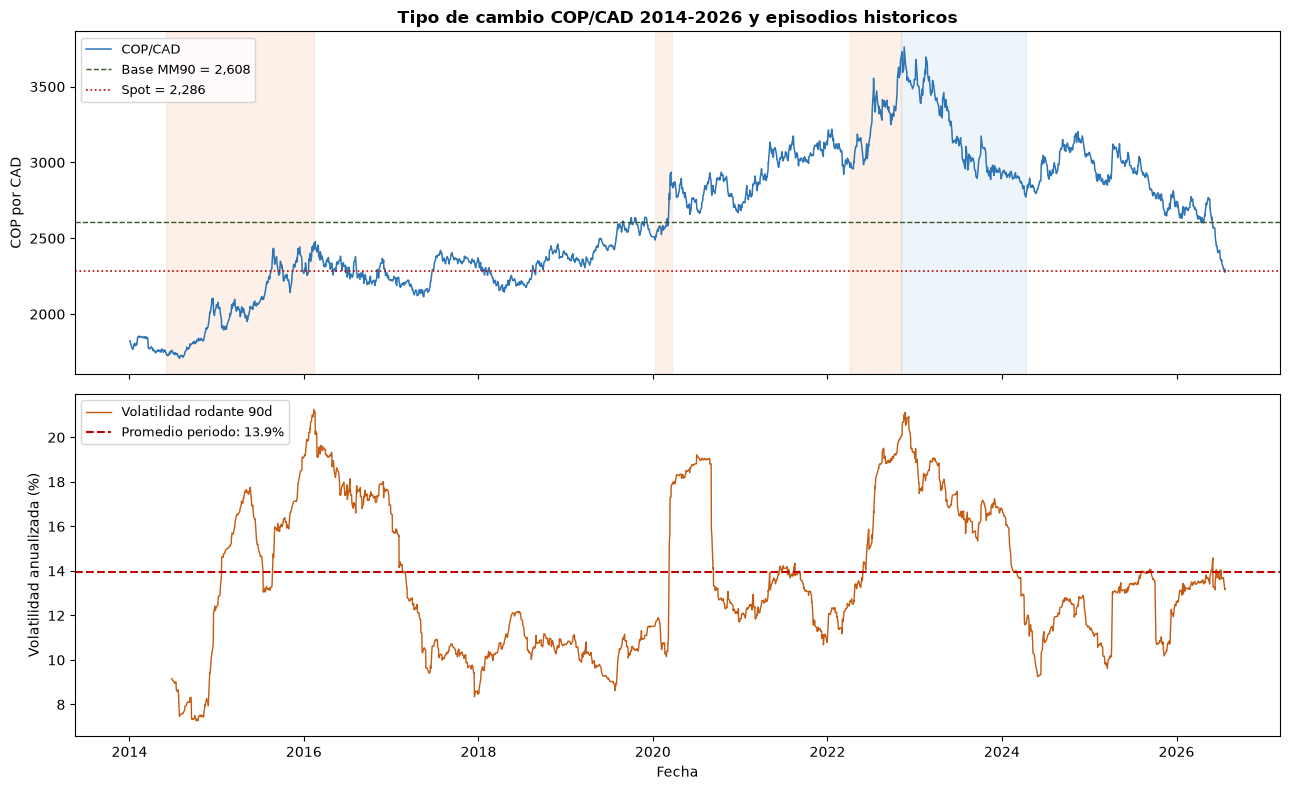

In [23]:
VERDE, AZUL, ROJO, NARANJA = '#375623', '#2E75B6', '#C00000', '#C55A11'

# --- Figura 4: serie COP/CAD, volatilidad rodante y episodios ---------------
fx['vol_rodante_90d'] = fx['retorno_log'].rolling(90).std() * np.sqrt(p['dias_habiles_anio'])
fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
a1.plot(fx.fecha, fx.COP_CAD, color=AZUL, lw=1.1, label='COP/CAD')
a1.axhline(fx_base, color=VERDE, ls='--', lw=1, label=f'Base MM90 = {fx_base:,.0f}')
a1.axhline(fx_spot, color=ROJO, ls=':', lw=1.2, label=f'Spot = {fx_spot:,.0f}')
for _, e in eps.iterrows():
    fi, ff = pd.Timestamp(e.fecha_inicio), pd.Timestamp(e.fecha_fin)
    if ff >= fx.fecha.min() and fi <= fx.fecha.max():
        a1.axvspan(max(fi, fx.fecha.min()), ff, alpha=.18, zorder=0,
                   color=('#F4B183' if e.tipo_movimiento == 'Devaluacion' else '#9DC3E6'))
a1.set_ylabel('COP por CAD'); a1.legend(loc='upper left', fontsize=9)
a1.set_title('Tipo de cambio COP/CAD 2014-2026 y episodios historicos', fontweight='bold')
a2.plot(fx.fecha, fx.vol_rodante_90d*100, color=NARANJA, lw=1, label='Volatilidad rodante 90d')
a2.axhline(vol_anual*100, color=ROJO, ls='--', label=f'Promedio periodo: {vol_anual*100:.1f}%')
a2.set_ylabel('Volatilidad anualizada (%)'); a2.set_xlabel('Fecha'); a2.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.savefig(f'{OUT}/figures/figura_04_copcad_volatilidad.png', dpi=150, bbox_inches='tight')
plt.show()

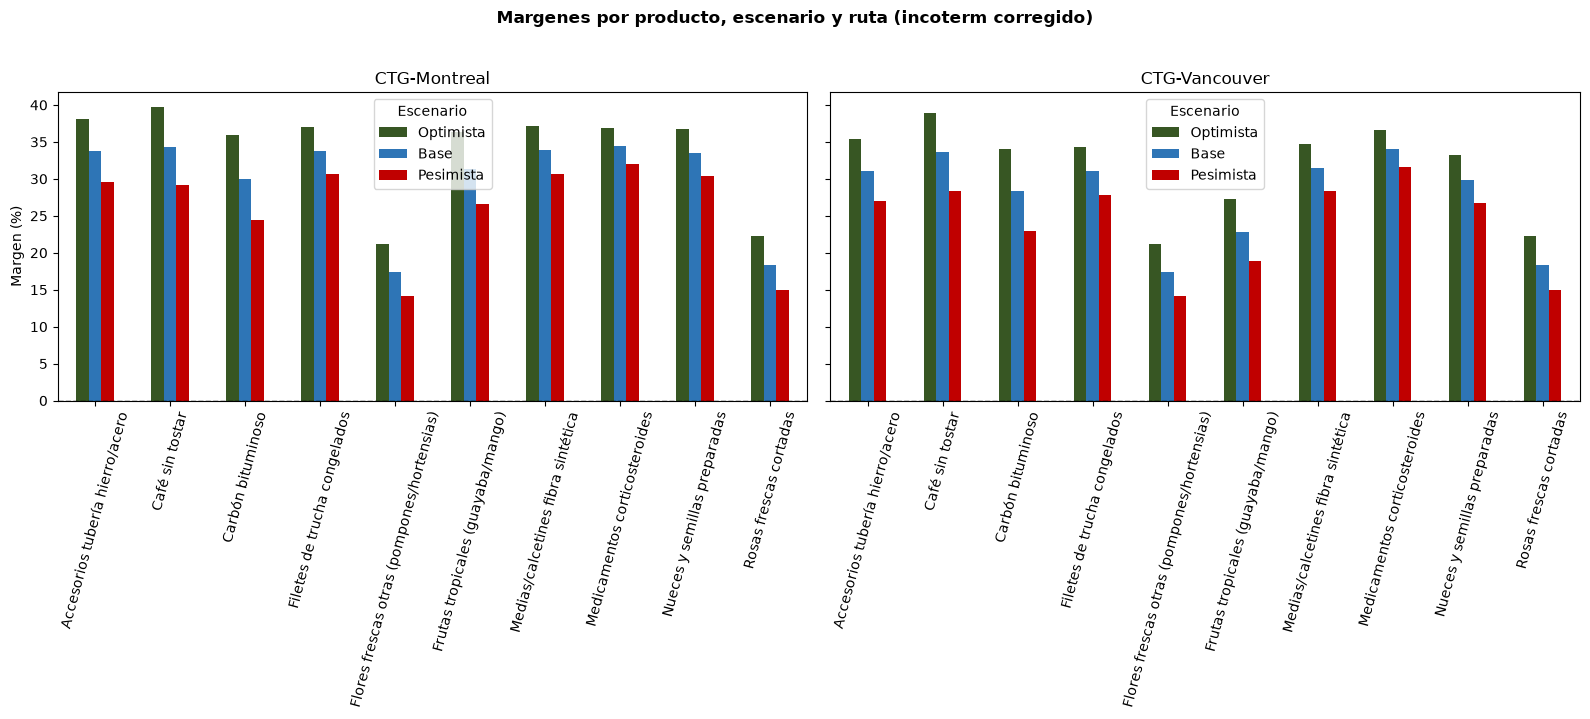

In [24]:
# --- Figura 5: margenes por escenario y ruta -------------------------------
COL = {'Optimista': VERDE, 'Base': AZUL, 'Pesimista': ROJO}
fig, ejes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, ruta in zip(ejes, tarifa):
    piv = (tabla_margenes[tabla_margenes.ruta == ruta]
           .pivot_table(index='producto', columns='escenario', values='margen_pct')
           [['Optimista', 'Base', 'Pesimista']])
    piv.plot(kind='bar', ax=ax, color=[COL[c] for c in piv.columns])
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.set_title(ruta); ax.set_ylabel('Margen (%)'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=75); ax.legend(title='Escenario')
plt.suptitle('Margenes por producto, escenario y ruta (incoterm corregido)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{OUT}/figures/figura_05_margenes_escenarios.png', dpi=150, bbox_inches='tight')
plt.show()

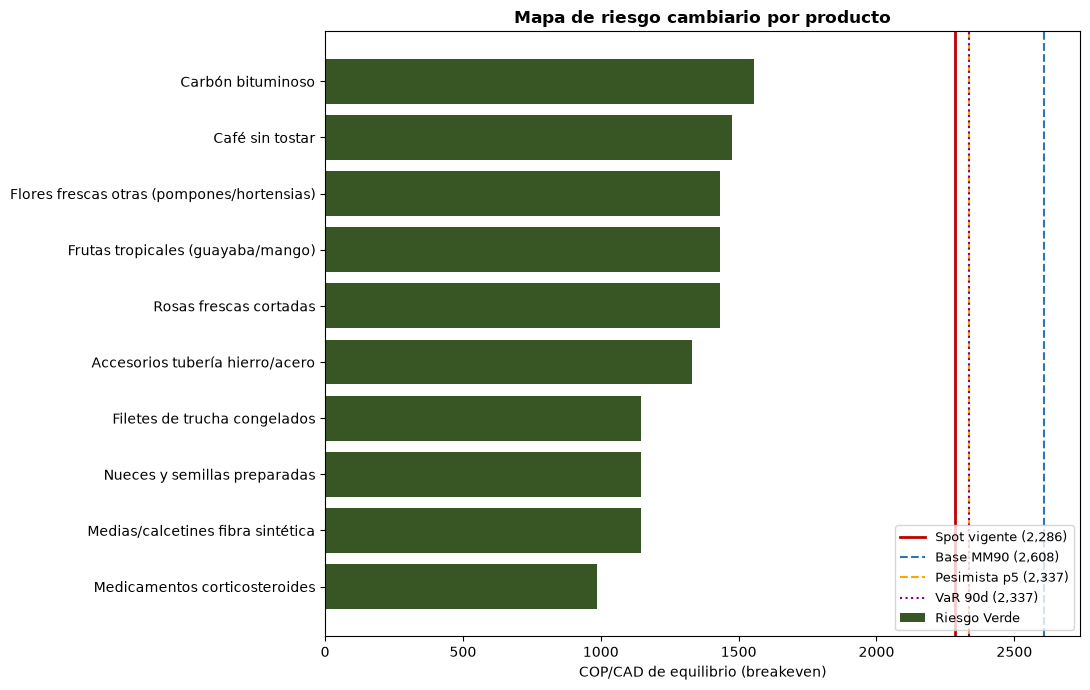

In [25]:
# --- Figura 6: mapa de riesgo breakeven ------------------------------------
from matplotlib.patches import Patch
CR = {'Verde': VERDE, 'Amarillo': '#BF8F00', 'Rojo': ROJO}
bmtl = tabla_be[tabla_be.ruta == 'CTG-Montreal'].sort_values('breakeven')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(bmtl.producto, bmtl.breakeven, color=[CR[x] for x in bmtl.riesgo])
l1 = ax.axvline(fx_spot, color=ROJO, ls='-', lw=2)
l2 = ax.axvline(fx_base, color=AZUL, ls='--')
l3 = ax.axvline(ESC['Pesimista'], color='orange', ls='--')
l4 = ax.axvline(fx_var90, color='purple', ls=':')
ax.set_xlabel('COP/CAD de equilibrio (breakeven)')
ax.set_title('Mapa de riesgo cambiario por producto', fontweight='bold')
ax.legend([l1, l2, l3, l4] + [Patch(facecolor=CR[n]) for n in bmtl.riesgo.unique()],
          [f'Spot vigente ({fx_spot:,.0f})', f'Base MM90 ({fx_base:,.0f})',
           f'Pesimista p5 ({ESC["Pesimista"]:,.0f})', f'VaR 90d ({fx_var90:,.0f})']
          + [f'Riesgo {n}' for n in bmtl.riesgo.unique()], loc='lower right', fontsize=9)
plt.tight_layout(); plt.savefig(f'{OUT}/figures/figura_06_mapa_riesgo_breakeven.png', dpi=150, bbox_inches='tight')
plt.show()

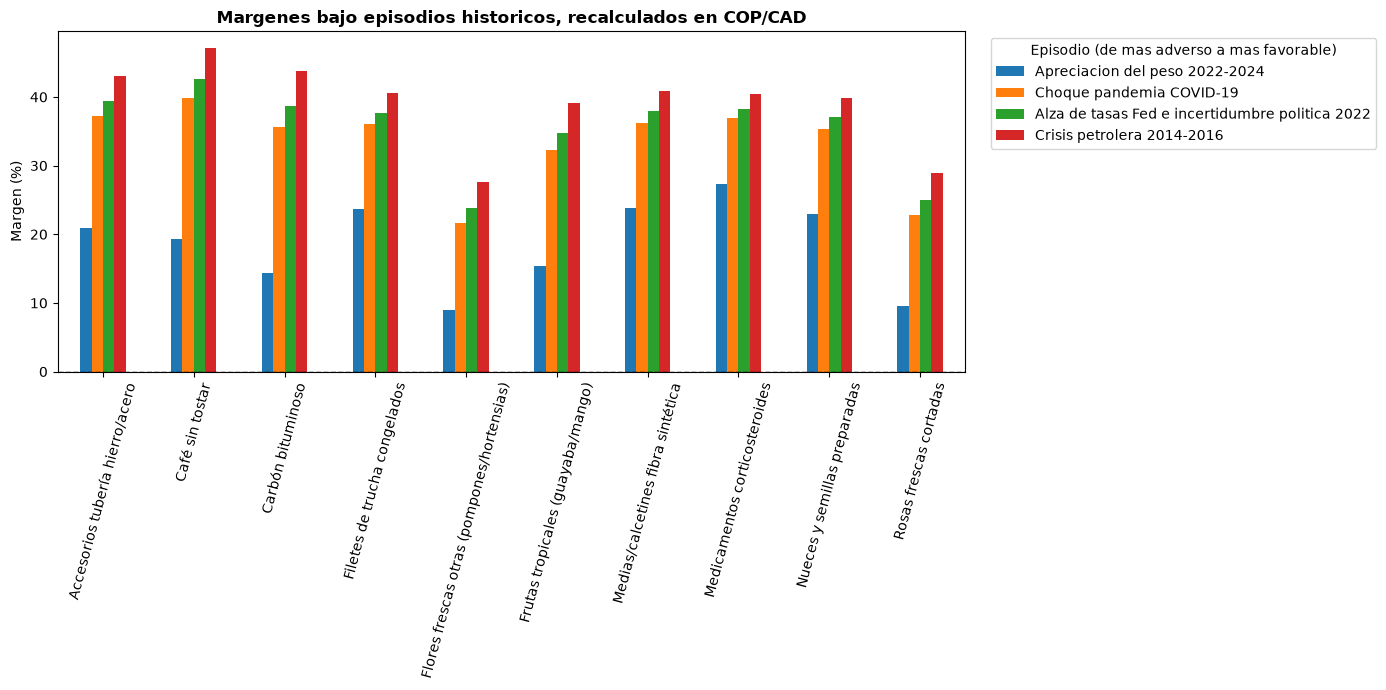

In [26]:
# --- Figura 7: estres historico (episodios en COP/CAD) ---------------------
fig, ax = plt.subplots(figsize=(14, 7))
orden = eps.sort_values('pct_cambio_copcad').nombre_episodio.tolist()
piv = tabla_stress.pivot_table(index='producto', columns='episodio',
                               values='margen_pct', aggfunc='mean')[orden]
piv.plot(kind='bar', ax=ax)
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_ylabel('Margen (%)'); ax.set_xlabel('')
ax.set_title('Margenes bajo episodios historicos, recalculados en COP/CAD', fontweight='bold')
ax.tick_params(axis='x', rotation=75)
ax.legend(title='Episodio (de mas adverso a mas favorable)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.savefig(f'{OUT}/figures/figura_07_stress_testing.png', dpi=150, bbox_inches='tight')
plt.show()

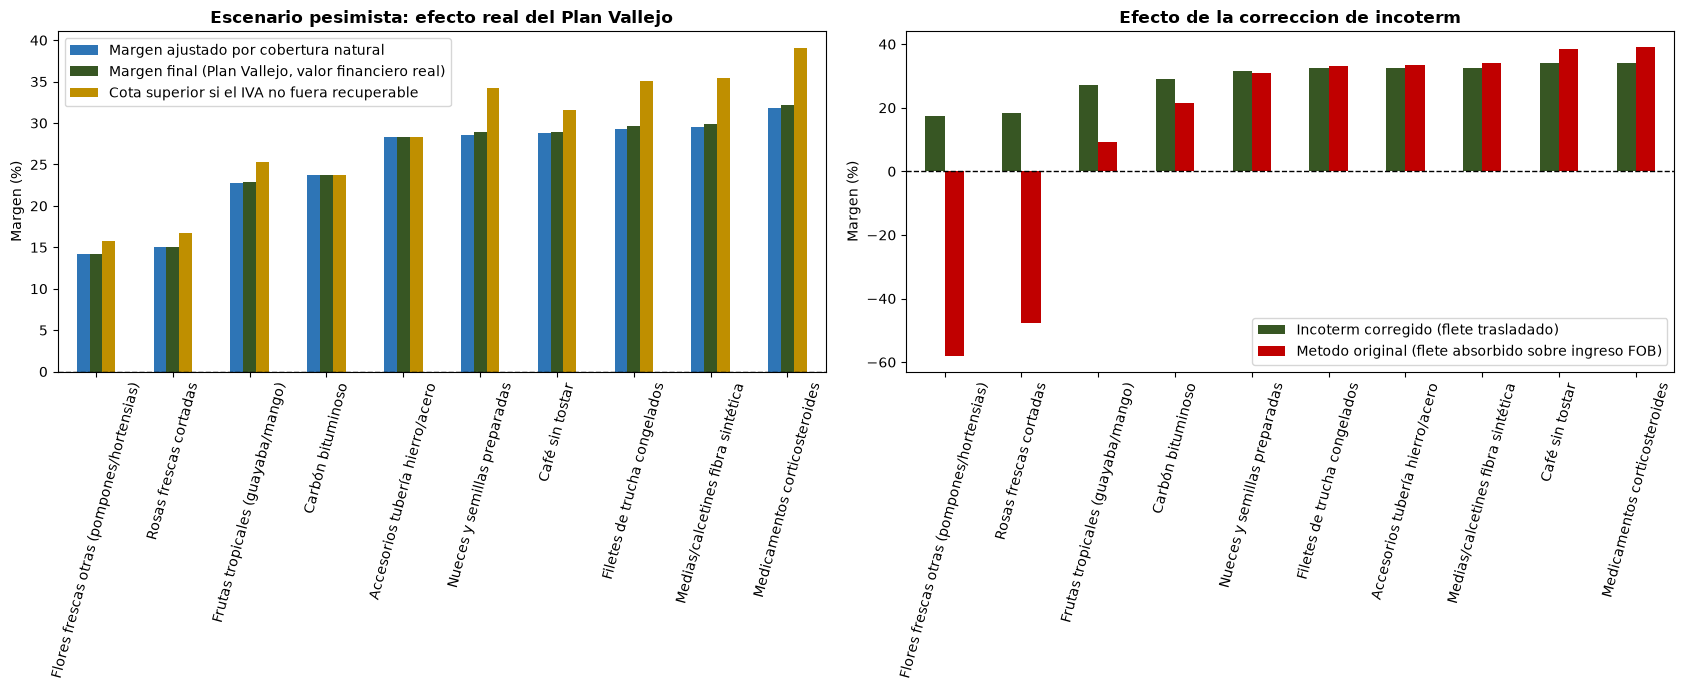

In [27]:
# --- Figura 8: progresion del margen y contraste con el metodo original ----
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 7))
d1 = (fin[fin.escenario == 'Pesimista']
      .groupby('producto')[['margen_pct', 'margen_final_pct', 'margen_cota_superior_pct']]
      .mean().sort_values('margen_final_pct'))
d1.plot(kind='bar', ax=a1, color=[AZUL, VERDE, '#BF8F00'])
a1.axhline(0, color='black', ls='--', lw=1); a1.set_ylabel('Margen (%)'); a1.set_xlabel('')
a1.tick_params(axis='x', rotation=75)
a1.legend(a1.containers, ['Margen ajustado por cobertura natural',
                          'Margen final (Plan Vallejo, valor financiero real)',
                          'Cota superior si el IVA no fuera recuperable'])
a1.set_title('Escenario pesimista: efecto real del Plan Vallejo', fontweight='bold')

d2 = (tabla_margenes[tabla_margenes.escenario == 'Base']
      .groupby('producto')[['margen_pct', 'margen_pct_metodo_original']]
      .mean().sort_values('margen_pct'))
d2.plot(kind='bar', ax=a2, color=[VERDE, ROJO])
a2.axhline(0, color='black', ls='--', lw=1); a2.set_ylabel('Margen (%)'); a2.set_xlabel('')
a2.tick_params(axis='x', rotation=75)
a2.legend(a2.containers, ['Incoterm corregido (flete trasladado)',
                          'Metodo original (flete absorbido sobre ingreso FOB)'])
a2.set_title('Efecto de la correccion de incoterm', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{OUT}/figures/figura_08_margen_bruto_vs_ajustado.png', dpi=150, bbox_inches='tight')
plt.show()

## 14 · Guardado y verificación de integridad

In [28]:
salidas = {
    'tabla_00_registro_correcciones.xlsx': OVERRIDES,
    'tabla_04_indicadores_riesgo.xlsx': pd.DataFrame(
        [{'indicador': 'Volatilidad anualizada', 'valor_pct': vol_anual*100},
         {'indicador': 'VaR 1d 95%', 'valor_pct': v95*100},
         {'indicador': 'VaR 1d 99%', 'valor_pct': v99*100},
         {'indicador': 'Expected Shortfall 95%', 'valor_pct': es95*100}] +
        [{'indicador': f'VaR {int(x.horizonte_dias)}d 95% (empirico)', 'valor_pct': x.var_empirico*100}
         for x in mh.itertuples()]),
    'tabla_04b_var_multihorizonte.xlsx': mh,
    'tabla_05_margenes_escenarios.xlsx': tabla_margenes,
    'tabla_06_breakeven.xlsx': tabla_be,
    'tabla_06b_logistica_por_modo.xlsx': fletes,
    'tabla_08_episodios_recalculados.xlsx': eps[
        ['nombre_episodio', 'tipo_movimiento', 'fecha_inicio', 'fecha_fin',
         'pct_cambio_trm_original', 'copcad_inicio', 'copcad_fin', 'pct_cambio_copcad', 'error_pp']],
    'tabla_08b_stress_testing.xlsx': tabla_stress,
    'tabla_08c_margen_al_spot_vigente.xlsx': tabla_hoy,
    'tabla_09_costo_capital.xlsx': cap,
    'tabla_10_cobertura_costo_beneficio.xlsx': tabla_cob,
    'tabla_10b_vulnerabilidad_relativa.xlsx': vuln[
        ['producto', 'ruta', 'margen_cop', 'perdida_var90_cop', 'vulnerabilidad_rel_pct']],
    'tabla_11_margen_final_ajustado.xlsx': fin,
    'tabla_12_sensibilidad_pass_through.xlsx': tabla_sens_pt,
    'tabla_13_sensibilidad_factor_costo.xlsx': tabla_sens_fc,
    'tabla_14_exposicion_cambiaria.xlsx': tabla_elast,
}
for nombre, df in salidas.items():
    df.to_excel(f'{OUT}/tables/{nombre}', index=False)

figuras = ['figura_04_copcad_volatilidad.png', 'figura_05_margenes_escenarios.png',
           'figura_06_mapa_riesgo_breakeven.png', 'figura_07_stress_testing.png',
           'figura_08_margen_bruto_vs_ajustado.png']

chk = ([{'artefacto': n, 'tipo': 'tabla', 'filas': len(d),
         'ok': os.path.exists(f'{OUT}/tables/{n}') and len(d) > 0} for n, d in salidas.items()]
       + [{'artefacto': n, 'tipo': 'figura',
           'filas': round(os.path.getsize(f'{OUT}/figures/{n}')/1024, 1) if os.path.exists(f'{OUT}/figures/{n}') else 0,
           'ok': os.path.exists(f'{OUT}/figures/{n}') and os.path.getsize(f'{OUT}/figures/{n}') > 20480}
          for n in figuras])
checklist = pd.DataFrame(chk)
display(checklist)
print(f'\nArtefactos: {len(checklist)} | Todos correctos: {checklist.ok.all()}')
print(f'Pruebas del modelo: {len(suite_pruebas())} fallos')
assert checklist.ok.all() and not suite_pruebas()
print(f'\nCuaderno original y outputs/ intactos. Resultados nuevos en {OUT}/')

,artefacto,tipo,filas,ok
0,tabla_00_registro_correcciones.xlsx,tabla,2.0,True
1,tabla_04_indicadores_riesgo.xlsx,tabla,7.0,True
2,tabla_04b_var_multihorizonte.xlsx,tabla,3.0,True
3,tabla_05_margenes_escenarios.xlsx,tabla,60.0,True
4,tabla_06_breakeven.xlsx,tabla,20.0,True
5,tabla_06b_logistica_por_modo.xlsx,tabla,20.0,True
6,tabla_08_episodios_recalculados.xlsx,tabla,4.0,True
7,tabla_08b_stress_testing.xlsx,tabla,80.0,True
8,tabla_08c_margen_al_spot_vigente.xlsx,tabla,20.0,True
9,tabla_09_costo_capital.xlsx,tabla,60.0,True



Artefactos: 21 | Todos correctos: True
Pruebas del modelo: 0 fallos

Cuaderno original y outputs/ intactos. Resultados nuevos en ../outputs_v2/


## 15 · Cierre — qué queda firme y qué sigue abierto

**Firme.** El módulo estadístico replica y mejora al original: serie COP/CAD 2014-2026 desde fuente
oficial con respaldo local funcional, alineación temporal TRM↔BoC, VaR y Expected Shortfall
históricos, cuantiles multi-horizonte empíricos en lugar de escalado √T, backtest de Kupiec fuera de
muestra y Jarque-Bera con los momentos correctos. La ecuación de margen existe una sola vez, el
breakeven se resuelve analíticamente incluyendo la cobertura natural, y la suite de pruebas verifica
propiedades que pueden fallar en vez de identidades algebraicas.

**Corregido y verificable en las tablas.** Coherencia de incoterm, episodios en COP/CAD, signo del
forward, valor financiero del Plan Vallejo, modo de transporte real por producto, tasa de fondeo
PYME, costos accesorios de exportación, y tipo de cambio vigente.

**Abierto — requiere recolección de datos, no código:**

1. **Factor de costo de producción por sector.** Es el supuesto que gobierna todo el resultado.
   Mientras sea uniforme, el modelo no puede discriminar entre productos y ningún ranking de
   rentabilidad por producto es defendible. Fuentes a consultar: FNC (café), Asocolflores (flores),
   Fedeacua (trucha), ANDI (farmacéutico y siderúrgico), Fenalcarbón (carbón).
2. **Tarifa de flete aéreo Bogotá–Canadá** y **flete a granel para carbón**: los valores usados son
   estimaciones de orden de magnitud declaradas como tales en `PARAMS`, no cotizaciones.
3. **Incoterm real de cada operación** y grado efectivo de traslado del flete al comprador.
4. **Precios de referencia** distintos del café: los 9 restantes son valores unitarios de Trade Map
   2024, no precios de mercado de 2026.
5. **Spread real del NDF** cotizado por un banco para el ticket típico de una PYME.
6. Segunda cotización de flete Cartagena–Vancouver 20 pies: la única disponible es más cara que la
   de 40 pies, lo que sugiere que no es una tarifa FCL comparable.